In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## LIMPIEZA DEL DATASET

ANTES DE REALIZAR EL ANALISIS INICIAL SE TRATAN LOS NULOS, OUTLIERS Y DUPLICADOS\
PARA HACERLO DE FORMA ORDENADA IREMOS VARIABLE A VARIABLE 


In [2]:
import pandas as pd

df=pd.read_csv("output/Libro1.csv", sep=";")
pd.set_option('display.max_columns', None)


In [3]:
df.info()

cols = ["Ambientes", "Dormitorios", "Banos", 
        "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2"]

df[cols] = df[cols].astype("Int64")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18128 entries, 0 to 18127
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Precio             18128 non-null  object 
 1   Expensas           11155 non-null  object 
 2   Calle              18128 non-null  object 
 3   Altura             16278 non-null  float64
 4   Piso               16278 non-null  object 
 5   Detalles           18038 non-null  object 
 6   Caracteristicas    18003 non-null  object 
 7   Barrio             18122 non-null  object 
 8   Tipo_Propiedad     18122 non-null  object 
 9   Dormitorios        14638 non-null  float64
 10  Banos              17318 non-null  float64
 11  Ambientes          17856 non-null  float64
 12  Antiguedad         11180 non-null  float64
 13  Sup_Cubierta_m2    17289 non-null  float64
 14  Sup_Total_m2       17584 non-null  float64
 15  Latitud            17807 non-null  float64
 16  Longitud           178

In [4]:
# NOS QUEDAMOS CON AQUELLAS COLUMNAS QUE PUEDAN SER DE UTILIDAD PARA EL ANALISIS
# EXCEPTO LINK, LA CUAL NOS LA QUEDAREMOS PARA PODER TRACKEAR DE ORIGEN CIERTAS PROPIEDADES QUE NOS HAGAN RUIDO

columnas_drop = [
    "Calle",
    "Altura",
    "Detalles",
    "Caracteristicas",
    "Tipo_Propiedad"
]

df = df.drop(columns=columnas_drop)

In [5]:
# CONVERTIMOS A NUMERICO EL PRECIO Y DROPEAMOS VALORES NEGATIVOS, IGUALES A 0 O NULOS
# DECIDIMOS DROPEAR LOS PRECIOS CON ESTOS VALORES DADO QUE ES LA COLUMNA PRINCIPAL Y TARGET
# Y NO QUEREMOS ENSUCIAR LA COLUMNA CON INFORMACION IMPUTADA EN ESTE CASO

df["Precio"] = (
    df["Precio"]
    .str.replace("USD ", "", regex=False)
    .str.replace(".", "", regex=False)
    .replace("Consultar", "0")
    .astype(int)
)

# Cantidad de precios <= 0
cantidad_precios_invalidos = (df["Precio"] <= 0).sum()

print(f"Cantidad de precios <= 0: {cantidad_precios_invalidos}")

# Dropear precios <= 0
df = df[df["Precio"] > 0]

cantidad_precios_nulos = df["Precio"].isna().sum()

print(f"Cantidad de precios nulos: {cantidad_precios_nulos}")

Cantidad de precios <= 0: 175
Cantidad de precios nulos: 0


In [6]:
# PARA ESTE ANALISIS TOMAREMOS PROPIEDADES CON UN PRECIO MAYOR A 20.000 DOLARES

propiedades_precio_bajo = df[df["Precio"] < 20_000]

print(f"Cantidad de propiedades con precio < 20.000: {len(propiedades_precio_bajo)}")


Cantidad de propiedades con precio < 20.000: 17


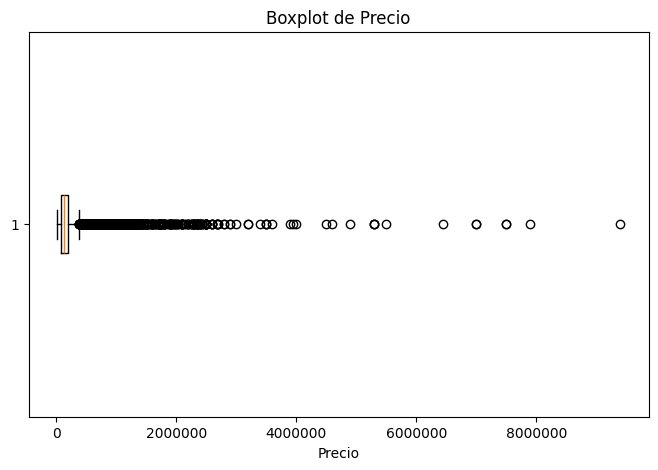

In [7]:
# REVISAMOS OUTLIERS, DADO QUE TAMPOCO QUEREMOS PROPIEDADES CON PRECIOS EXCESIVAMENTE ALTOS, DADO QUE LUEGO PUEDEN DIFICULTAR POSIBLES MODELOS
# O GRAFICOS CORRIDOS

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df["Precio"].dropna(), vert=False)

ax.set_title("Boxplot de Precio")
ax.set_xlabel("Precio")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="x")

plt.show()

In [8]:
# VER CANTIDAD DE PROPIEDADES CUYO VALOR SUPEREN 1.000.000
propiedades_mas_1m = df[df["Precio"] > 1_000_000]

resumen_barrios_mas_1m = (
    propiedades_mas_1m
    .groupby("Barrio")
    .size()
    .rename("cantidad_mas_1m")
    .to_frame()
)

resumen_barrios_mas_1m["total_barrio"] = (
    df.groupby("Barrio")
    .size()
)

resumen_barrios_mas_1m["porcentaje_mas_1m"] = (
    resumen_barrios_mas_1m["cantidad_mas_1m"]
    / resumen_barrios_mas_1m["total_barrio"]
    * 100
).round(2)

resumen_barrios_mas_1m = (
    resumen_barrios_mas_1m
    .sort_values("cantidad_mas_1m", ascending=False)
    .head(10)
)

print(resumen_barrios_mas_1m)

                    cantidad_mas_1m  total_barrio  porcentaje_mas_1m
Barrio                                                              
Puerto Madero                   230           985              23.35
Recoleta                         31           959               3.23
Retiro                           22           810               2.72
Palermo Chico                    15            74              20.27
Nuñez                            12           794               1.51
Palermo                          12           606               1.98
Belgrano                          9           693               1.30
Saavedra                          5           968               0.52
Belgrano Barrancas                3            42               7.14
Belgrano Chico                    3            49               6.12


In [9]:
# DADO QUE LA GRAN MAYORIA DE REGISTROS CORRESPONDE A UN SOLO BARRIO (PUERTO MADERO)
# SEREMOS UN POCO PERMISIVOS PARA NO SESGAR EL ANALISIS DE DICHO BARRIO Y DROPEAREMOS LOS QUE SEAN MAYORES A 1.000.0000

df = df[df["Precio"] <= 1_000_000]

In [10]:
# AHORA LIMPIAREMOS EXPENSAS

df["Expensas"] = (
    df["Expensas"]
    .str.replace("$ ", "", regex=False)
    .str.replace(".", "", regex=False)
    .replace("consultar", "0")
    .astype(float)
    .fillna(0)
    .astype(int)
)
# Cantidad de expensas < 0
cantidad_expensas_invalidas = (df["Expensas"] < 0).sum()
porcentaje_expensas_invalidas = cantidad_expensas_invalidas / len(df) * 100

print(f"Cantidad de expensas < 0: {cantidad_expensas_invalidas}")
print(f"Porcentaje de expensas < 0: {porcentaje_expensas_invalidas:.2f}%")


# Cantidad de expensas = 0
cantidad_expensas_cero = (df["Expensas"] == 0).sum()
porcentaje_expensas_cero = cantidad_expensas_cero / len(df) * 100

print(f"Cantidad de expensas = 0: {cantidad_expensas_cero}")
print(f"Porcentaje de expensas = 0: {porcentaje_expensas_cero:.2f}%")

# Cantidad de expensas nulas
cantidad_expensas_nulas = df["Expensas"].isna().sum()
porcentaje_expensas_nulas = cantidad_expensas_nulas / len(df) * 100

print(f"Cantidad de expensas nulas: {cantidad_expensas_nulas}")
print(f"Porcentaje de expensas nulas: {porcentaje_expensas_nulas:.2f}%")

Cantidad de expensas < 0: 0
Porcentaje de expensas < 0: 0.00%
Cantidad de expensas = 0: 6664
Porcentaje de expensas = 0: 37.87%
Cantidad de expensas nulas: 0
Porcentaje de expensas nulas: 0.00%


In [11]:
# CREEMOS QUE ESE 37% DE EXPENSAS = 0 FUE UN ERROR AL SCRAPPEAR
# DADO QUE EL NUMERO ES DEMASIADO ALTO NO NOS CONVENCE DROPEAR NI IMPUTAR
# LA COLUMNA PODRIA ELIMINARSE LUEGO, PERO POR EL MOMENTO LA DEJAREMOS PARA REALIZAR EL EDA AL 63% DE DATOS QUE TENEMOS
# DADO QUE ES MUY RARO QUE EN CAPITAL NO HAYA EXPENSAS Y POR LA CANTIDAD LOS PONDREMOS COMO NULL PARA QUE EN LOS GRAFICOS POSTERIORES NO INTERFIERAN
df = df[df["Expensas"] != 0]

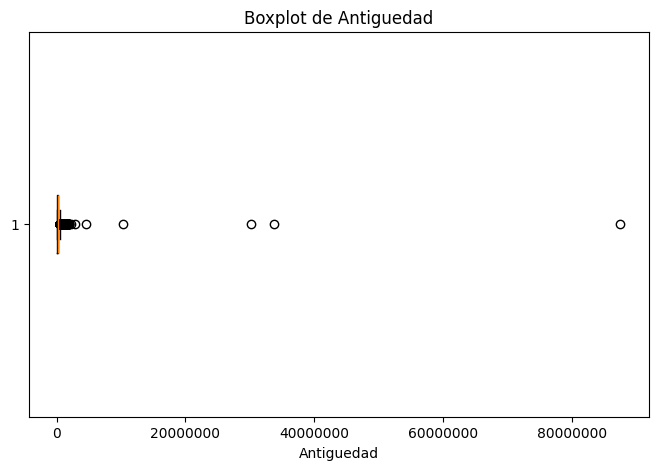

In [12]:
# REVISAMOS SI HAY ALGUN OUTLIER

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df["Expensas"].dropna(), vert=False)

ax.set_title("Boxplot de Antiguedad")
ax.set_xlabel("Antiguedad")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="x")

plt.show()

In [13]:
# NOS QUEDAREMOS CON LAS EXPENSAS CUYOS VALORES SEAN MENORES A 1 MILLON DE PESOS
cantidad_expensas_mas_1m = (df["Expensas"] > 1_000_000).sum()

print(f"Cantidad de expensas > 1.000.000: {cantidad_expensas_mas_1m}")

df = df[df["Expensas"] <= 1_000_000]

Cantidad de expensas > 1.000.000: 138


In [14]:
# CONVERTIMOS A INT LAS COL NUMERICAS

cols_int = [
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2",
    "Latitud",
    "Longitud"
]

df[cols_int] = df[cols_int].astype("Int64")

In [15]:
# DEL VISTAZO INICIAL AL DATASET TUVIMOS LAS SOSPECHA DE QUE MUCHAS COLUMNAS SE MULTIPLICARON POR 10 AL SCRAPPEAR
# REVISAMOS QUE PORCENTAJE TERMINA EN 0 PARA COMPROBAR

columnas = [
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Sup_Total_m2",
    "Sup_Cubierta_m2"
]

for col in columnas:
    print(f"\n{col}")
    print("Frecuencia de valores terminados en 0:")
    print((df[col].dropna() % 10 == 0).value_counts(normalize=True) * 100)


Dormitorios
Frecuencia de valores terminados en 0:
Dormitorios
True    100.0
Name: proportion, dtype: Float64

Banos
Frecuencia de valores terminados en 0:
Banos
True    100.0
Name: proportion, dtype: Float64

Ambientes
Frecuencia de valores terminados en 0:
Ambientes
True    100.0
Name: proportion, dtype: Float64

Sup_Total_m2
Frecuencia de valores terminados en 0:
Sup_Total_m2
True    100.0
Name: proportion, dtype: Float64

Sup_Cubierta_m2
Frecuencia de valores terminados en 0:
Sup_Cubierta_m2
True    100.0
Name: proportion, dtype: Float64


In [16]:
# DIVIDIMOS POR 10 PARA CORREGIR

cols = [
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]

df[cols] = df[cols] / 10

In [17]:
# REVISAMOS ANTIGUEDAD

cantidad_antiguedad_mas_200 = (df["Antiguedad"] > 200).sum()
porcentaje_antiguedad_mas_200 = cantidad_antiguedad_mas_200 / len(df) * 100

print(f"Cantidad de antigüedades > 200: {cantidad_antiguedad_mas_200}")
print(f"Porcentaje de antigüedades > 200: {porcentaje_antiguedad_mas_200:.2f}%")


Cantidad de antigüedades > 200: 21
Porcentaje de antigüedades > 200: 0.19%


In [18]:
# NOS DIMOS CUENTA QUE ALGUNOS VALORES DE ANTIGUEDAD ERAN LOS AÑOS EN QUE SE CONSTRUYO (2011, 2025, etc) EN VEZ DE LA ANTIGUEDAD EN AÑOS

filas_a_corregir = df["Antiguedad"] > 1900

cantidad_a_corregir = filas_a_corregir.sum()

print(f"Cantidad de antigüedades cargadas como año: {cantidad_a_corregir}")

print("\nValores antes de corregir:")
print(df.loc[filas_a_corregir, "Antiguedad"].value_counts().sort_index())

df.loc[filas_a_corregir, "Antiguedad"] = (
    2026 - df.loc[filas_a_corregir, "Antiguedad"]
)

print("\nValores después de corregir:")
print(df.loc[filas_a_corregir, "Antiguedad"].value_counts().sort_index())


Cantidad de antigüedades cargadas como año: 21

Valores antes de corregir:
Antiguedad
1970.0     2
1981.0     2
2001.0     1
2024.0     1
2025.0    14
2026.0     1
Name: count, dtype: Int64

Valores después de corregir:
Antiguedad
0.0      1
1.0     14
2.0      1
25.0     1
45.0     2
56.0     2
Name: count, dtype: Int64


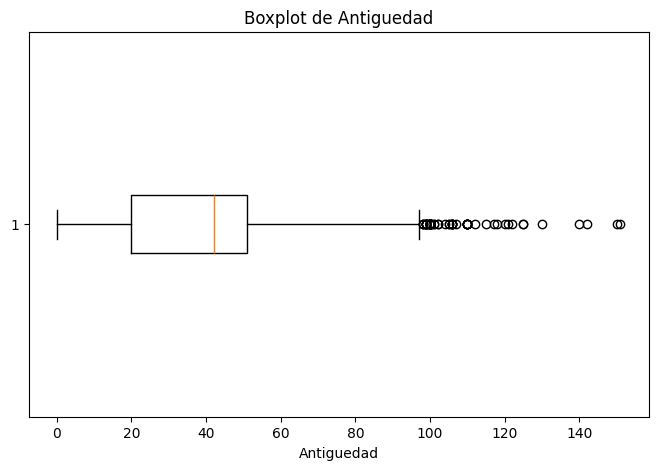

In [19]:
# REVISAMOS SI FALTA ALGUN OUTLIER

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df["Antiguedad"].dropna(), vert=False)

ax.set_title("Boxplot de Antiguedad")
ax.set_xlabel("Antiguedad")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="x")

plt.show()

In [20]:
# ASI COMO SUCEDIO CON EXPENSAS, TAMBIEN OBTUVIMOS UNA GRAN CANTIDAD DE NULOS
# ASI COMO EN EXPENSAS DECIDIMOS NO DROPEAR NI IMPUTARLOS DADO QUE ES UNA GRAN CANTIDAD DE DATOS
# EN UN FUTURO ESTA COLUMNA PODRIA DROPEARSE, PERO POR EL MOMENTO LA DEJAREMOS PARA ANALIZAR EL 63% DE PROPIEDADES CON ANTIGUEDAD

cantidad_antiguedad_nulas = df["Antiguedad"].isna().sum()
porcentaje_antiguedad_nulas = cantidad_antiguedad_nulas / len(df) * 100

print(f"Cantidad de antigüedades nulas: {cantidad_antiguedad_nulas}")
print(f"Porcentaje de antigüedades nulas: {porcentaje_antiguedad_nulas:.2f}%")

Cantidad de antigüedades nulas: 1849
Porcentaje de antigüedades nulas: 17.13%


In [21]:
# REVISAMOS SUP M2 (CUBIERTA Y TOTAL)

columnas_superficie = ["Sup_Cubierta_m2", "Sup_Total_m2"]

for col in columnas_superficie:
    cantidad_nulos = df[col].isna().sum()
    porcentaje_nulos = cantidad_nulos / len(df) * 100

    cantidad_menor_igual_cero = (df[col] <= 0).sum()
    porcentaje_menor_igual_cero = cantidad_menor_igual_cero / len(df) * 100

    print(f"\n{col}")
    print(f"Cantidad de nulos: {cantidad_nulos}")
    print(f"Porcentaje de nulos: {porcentaje_nulos:.2f}%")
    print(f"Cantidad <= 0: {cantidad_menor_igual_cero}")
    print(f"Porcentaje <= 0: {porcentaje_menor_igual_cero:.2f}%")

cantidad_cubierta_mayor_total = (
    df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]
).sum()

porcentaje_cubierta_mayor_total = (
    cantidad_cubierta_mayor_total / len(df) * 100
)

print("\nSup_Cubierta_m2 > Sup_Total_m2")
print(f"Cantidad: {cantidad_cubierta_mayor_total}")
print(f"Porcentaje: {porcentaje_cubierta_mayor_total:.2f}%")


Sup_Cubierta_m2
Cantidad de nulos: 368
Porcentaje de nulos: 3.41%
Cantidad <= 0: 0
Porcentaje <= 0: 0.00%

Sup_Total_m2
Cantidad de nulos: 183
Porcentaje de nulos: 1.70%
Cantidad <= 0: 0
Porcentaje <= 0: 0.00%

Sup_Cubierta_m2 > Sup_Total_m2
Cantidad: 8
Porcentaje: 0.07%


In [22]:
# INTERCAMBIAMOS LOS VALORES CUYA SUP CUBIERTA SEA MAYOR A LA TOTAL

mask_cubierta_mayor_total = df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]

df.loc[mask_cubierta_mayor_total, ["Sup_Cubierta_m2", "Sup_Total_m2"]] = (
    df.loc[mask_cubierta_mayor_total, ["Sup_Total_m2", "Sup_Cubierta_m2"]].values
)


In [23]:
# NOS QUEDAMOS SOLAMENTE CON LAS SUP TOTAL Y CUBIERTA MAYORES A 10 (UN VALOR MINIMO CON SENTIDO)

df = df[df["Sup_Total_m2"] >= 10]

df = df[df["Sup_Cubierta_m2"] >= 10]

In [24]:
# Tiene Sup_Cubierta_m2 pero NO Sup_Total_m2
cubierta_sin_total = (
    df["Sup_Cubierta_m2"].notna() &
    df["Sup_Total_m2"].isna()
).sum()

# Tiene Sup_Total_m2 pero NO Sup_Cubierta_m2
total_sin_cubierta = (
    df["Sup_Total_m2"].notna() &
    df["Sup_Cubierta_m2"].isna()
).sum()

print("Sup_Cubierta_m2 sin Sup_Total_m2:", cubierta_sin_total)
print("Sup_Total_m2 sin Sup_Cubierta_m2:", total_sin_cubierta)

Sup_Cubierta_m2 sin Sup_Total_m2: 0
Sup_Total_m2 sin Sup_Cubierta_m2: 0


In [25]:
# EN ESTE CASO DECIDIMOS LLENAR LOS NULOS DE AMBAS COLUMNAS EN BASE A LA OTRA
# EN ESTE CASO SOLO SE PUEDE HACER EN 289 CASOS DE SUP TOTAL
# SE CALCULA LA MEDIA DE LA DIFERENCIA ENTRE SUP TOTAL Y CUBIERTA PARA ELLO

pivot = df["Sup_Total_m2"] - df["Sup_Cubierta_m2"]
pivot = pivot[df["Sup_Total_m2"].notna() & df["Sup_Cubierta_m2"].notna()]

media_pivot = pivot.mean()

print(media_pivot)



6.024671210521263


In [26]:
# SE IMPUTA UN REDONDEO A 7

media_pivot = 7

mask = df["Sup_Total_m2"].notna() & df["Sup_Cubierta_m2"].isna()

df.loc[mask, "Sup_Cubierta_m2"] = (
    df.loc[mask, "Sup_Total_m2"] - media_pivot
)

In [27]:
# LOS QUE QUEDARON NULOS SE DROPEAN 

df = df.dropna(subset=["Sup_Cubierta_m2", "Sup_Total_m2"])

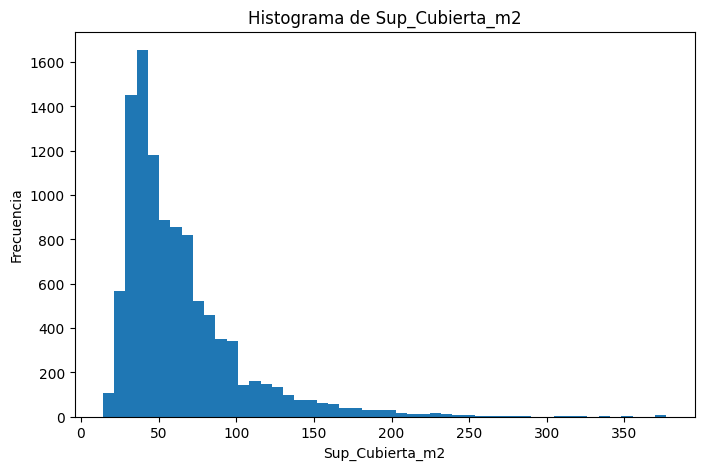

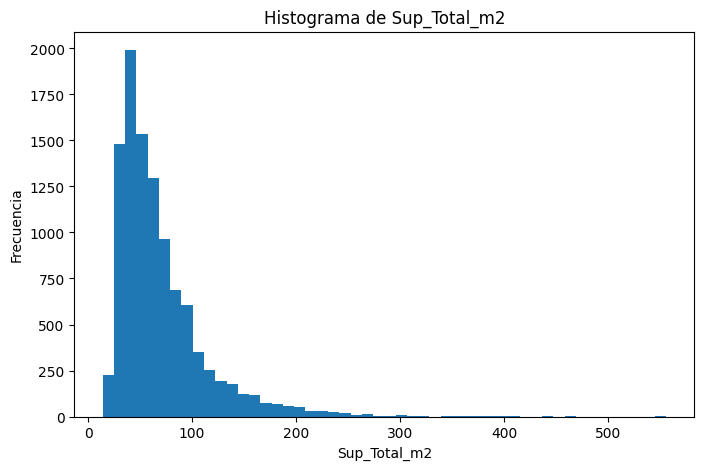

In [28]:
import matplotlib.pyplot as plt

columnas = ["Sup_Cubierta_m2", "Sup_Total_m2"]

for col in columnas:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=50
    )

    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.show()

In [29]:
# PARA ESTE ANALISIS NOS QUEDAMOS CON VALORES CUYA SUPERFICIE NO PASE Los 300 M2
df = df[
    (df["Sup_Cubierta_m2"] <= 300)
    & (df["Sup_Total_m2"] <= 300)
]

In [30]:
# AMBIENTES

cantidad_ambientes_invalidos = (df["Ambientes"] <= 0).sum()
porcentaje_ambientes_invalidos = cantidad_ambientes_invalidos / len(df) * 100

print(f"Cantidad de ambientes <= 0: {cantidad_ambientes_invalidos}")
print(f"Porcentaje de ambientes <= 0: {porcentaje_ambientes_invalidos:.2f}%")

cantidad_ambientes_nulos = df["Ambientes"].isna().sum()
porcentaje_ambientes_nulos = cantidad_ambientes_nulos / len(df) * 100

print(f"Cantidad de ambientes nulos: {cantidad_ambientes_nulos}")
print(f"Porcentaje de ambientes nulos: {porcentaje_ambientes_nulos:.2f}%")



Cantidad de ambientes <= 0: 21
Porcentaje de ambientes <= 0: 0.20%
Cantidad de ambientes nulos: 53
Porcentaje de ambientes nulos: 0.51%


In [31]:
# VAMOS A IMPUTAR ESTOS CASOS BASANDONOS EN LA SUP TOTAL CUBIERTA DADO QUE ES UNA COLUMNA MUY REPRESENTATIVA PARA LA CANTIDAD DE AMBIENTES
# USAREMOS LA MEDIANA


df.loc[df["Ambientes"] <= 0, "Ambientes"] = np.nan


bins = [0, 30, 45, 60, 80, 120, float("inf")]
labels = ["0-30", "30-45", "45-60", "60-80", "80-120", "120+"]

rango_sup_cubierta = pd.cut(
    df["Sup_Cubierta_m2"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

mediana_ambientes_por_sup = (
    df.groupby(rango_sup_cubierta, observed=True)["Ambientes"]
    .median()
)

print("Mediana de ambientes por rango de superficie cubierta:")
print(mediana_ambientes_por_sup)

ambientes_nulos_antes = df["Ambientes"].isna().sum()

mask = df["Ambientes"].isna() & df["Sup_Cubierta_m2"].notna()

df.loc[mask, "Ambientes"] = (
    rango_sup_cubierta[mask]
    .map(mediana_ambientes_por_sup)
)

ambientes_nulos_despues = df["Ambientes"].isna().sum()

print(f"\nAmbientes nulos antes: {ambientes_nulos_antes}")
print(f"Ambientes nulos después: {ambientes_nulos_despues}")
print(f"Ambientes imputados: {ambientes_nulos_antes - ambientes_nulos_despues}")

Mediana de ambientes por rango de superficie cubierta:
Sup_Cubierta_m2
0-30      1.0
30-45     2.0
45-60     3.0
60-80     3.0
80-120    4.0
120+      4.0
Name: Ambientes, dtype: Float64

Ambientes nulos antes: 74
Ambientes nulos después: 0
Ambientes imputados: 74


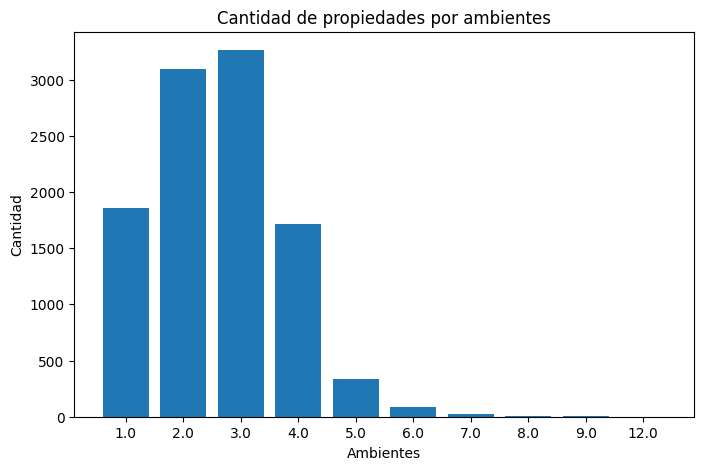

In [32]:
import matplotlib.pyplot as plt

conteo_ambientes = (
    df["Ambientes"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    conteo_ambientes.index.astype(str),
    conteo_ambientes.values
)

plt.title("Cantidad de propiedades por ambientes")
plt.xlabel("Ambientes")
plt.ylabel("Cantidad")

plt.show()

In [33]:
# PARA ESTE ANALISIS DECIDIMOS QUEDARNOS UNICAMENTE CON DEPARTAMENTO QUE TENGAN MAXIMO 7 AMBIENTES
df = df[df["Ambientes"] <= 7]

In [34]:
# REVISAMOS BAÑO

cantidad_banos_invalidos = (df["Banos"] <= 0).sum()
porcentaje_banos_invalidos = cantidad_banos_invalidos / len(df) * 100

print(f"Cantidad de baños <= 0: {cantidad_banos_invalidos}")
print(f"Porcentaje de baños <= 0: {porcentaje_banos_invalidos:.2f}%")

cantidad_banos_nulos = df["Banos"].isna().sum()
porcentaje_banos_nulos = cantidad_banos_nulos / len(df) * 100

print(f"Cantidad de baños nulos: {cantidad_banos_nulos}")
print(f"Porcentaje de baños nulos: {porcentaje_banos_nulos:.2f}%")

Cantidad de baños <= 0: 0
Porcentaje de baños <= 0: 0.00%
Cantidad de baños nulos: 268
Porcentaje de baños nulos: 2.58%


In [35]:
# IMPUTAREMOS ESE 4% DE NULOS USANDO LA MEDIANA DE BAÑOS POR AMBIENTE DADO QUE NOS PARECE UNA COLUMNA REPRESENTATIVA


mediana_banos_por_ambiente = df.groupby("Ambientes")["Banos"].median()

print("Mediana de baños por cantidad de ambientes:")
print(mediana_banos_por_ambiente)

cantidad_banos_nulos_antes = df["Banos"].isna().sum()
print(f"\nBaños nulos antes: {cantidad_banos_nulos_antes}")

mask = df["Banos"].isna() & df["Ambientes"].notna()

df.loc[mask, "Banos"] = df.loc[mask, "Ambientes"].map(mediana_banos_por_ambiente)

cantidad_banos_nulos_despues = df["Banos"].isna().sum()
print(f"Baños nulos después: {cantidad_banos_nulos_despues}")
print(f"Baños imputados: {cantidad_banos_nulos_antes - cantidad_banos_nulos_despues}")

Mediana de baños por cantidad de ambientes:
Ambientes
1.0    1.0
2.0    1.0
3.0    1.0
4.0    2.0
5.0    2.0
6.0    2.0
7.0    2.0
Name: Banos, dtype: Float64

Baños nulos antes: 268
Baños nulos después: 0
Baños imputados: 268


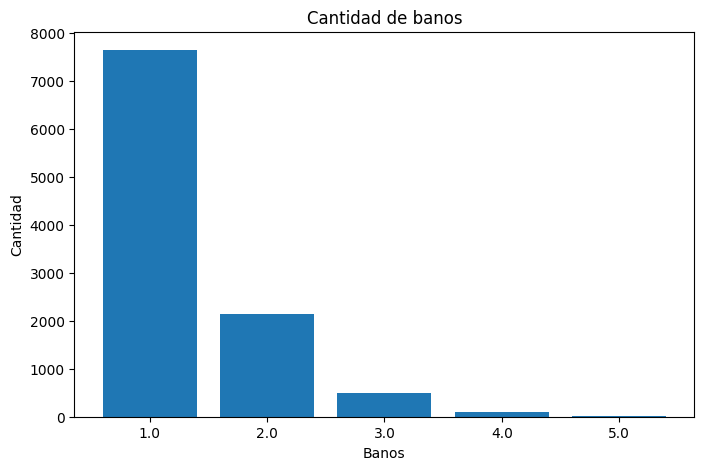

In [36]:
import matplotlib.pyplot as plt

conteo_ambientes = (
    df["Banos"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    conteo_ambientes.index.astype(str),
    conteo_ambientes.values
)

plt.title("Cantidad de banos")
plt.xlabel("Banos")
plt.ylabel("Cantidad")

plt.show()

In [37]:
# DROPEAMOS LOS CASOS OUTLIERS CON MAS DE 5 BAÑOS

df = df[df["Banos"] <= 5]

In [38]:
# ANALIZAMOS DORMITORIOS

cantidad_dormitorios_invalidos = (df["Dormitorios"] <= 0).sum()
porcentaje_dormitorios_invalidos = cantidad_dormitorios_invalidos / len(df) * 100

print(f"Cantidad de dormitorios <= 0: {cantidad_dormitorios_invalidos}")
print(f"Porcentaje de dormitorios <= 0: {porcentaje_dormitorios_invalidos:.2f}%")

cantidad_dormitorios_nulos = df["Dormitorios"].isna().sum()
porcentaje_dormitorios_nulos = cantidad_dormitorios_nulos / len(df) * 100

print(f"Cantidad de dormitorios nulos: {cantidad_dormitorios_nulos}")
print(f"Porcentaje de dormitorios nulos: {porcentaje_dormitorios_nulos:.2f}%")

Cantidad de dormitorios <= 0: 0
Porcentaje de dormitorios <= 0: 0.00%
Cantidad de dormitorios nulos: 1584
Porcentaje de dormitorios nulos: 15.26%


In [39]:
# DECIDIMOS IMPUTAR LOS DORMITORIOS POR LA CANTIDAD MEDIANA DE AMBIENTES, DADO QUE NOS PARECE UNA VARIABLE REPRESENTATIVA
# Imputación de dormitorios según ambientes

mediana_dormitorios_por_ambiente = (
    df.groupby("Ambientes")["Dormitorios"]
    .median()
)

print("Mediana de dormitorios por ambiente:")
print(
    mediana_dormitorios_por_ambiente
    .reset_index()
    .rename(columns={
        "Ambientes": "ambientes",
        "Dormitorios": "mediana_dormitorios"
    })
)

mask = df["Dormitorios"].isna() & df["Ambientes"].notna()

print("\nCantidad de dormitorios nulos a imputar por ambiente:")
print(
    df.loc[mask, "Ambientes"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={
        "index": "ambientes",
        "Ambientes": "cantidad_a_imputar"
    })
)

df.loc[mask, "Dormitorios"] = (
    df.loc[mask, "Ambientes"]
    .map(mediana_dormitorios_por_ambiente)
)

Mediana de dormitorios por ambiente:
   ambientes  mediana_dormitorios
0        1.0                  1.0
1        2.0                  1.0
2        3.0                  2.0
3        4.0                  3.0
4        5.0                  4.0
5        6.0                  4.0
6        7.0                  5.0

Cantidad de dormitorios nulos a imputar por ambiente:
   cantidad_a_imputar  count
0                 1.0   1475
1                 2.0     61
2                 3.0     32
3                 4.0     11
4                 5.0      4
5                 6.0      1


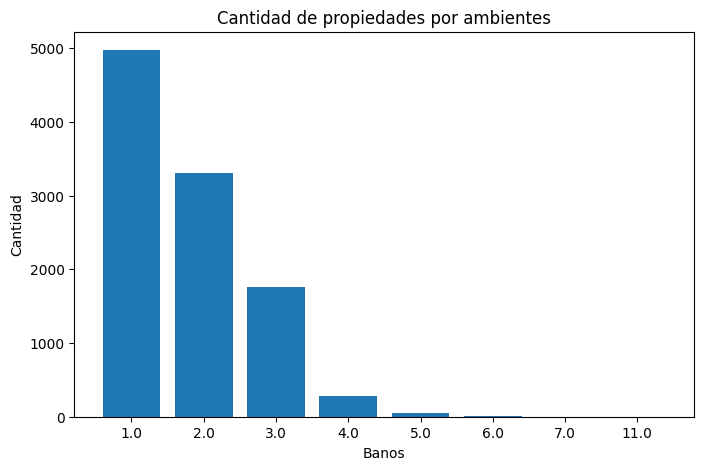

In [40]:
import matplotlib.pyplot as plt

conteo_ambientes = (
    df["Dormitorios"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    conteo_ambientes.index.astype(str),
    conteo_ambientes.values
)

plt.title("Cantidad de propiedades por ambientes")
plt.xlabel("Banos")
plt.ylabel("Cantidad")

plt.show()

In [41]:
# NOS QUEDAMOS CON LOS CASOS QUE TENGAN COMO MAXIMO 6 DORMITORIOS

df = df[df["Dormitorios"] <= 6]

In [42]:
# ANALIZAMOS PISO 
pisos_nulos_por_barrio = (
    df[df["Piso"].isna()]
    .groupby("Barrio")
    .size()
    .rename("cantidad_pisos_nulos")
    .to_frame()
)

pisos_nulos_por_barrio["total_barrio"] = (
    df.groupby("Barrio")
    .size()
)

pisos_nulos_por_barrio["porcentaje_pisos_nulos"] = (
    pisos_nulos_por_barrio["cantidad_pisos_nulos"]
    / pisos_nulos_por_barrio["total_barrio"]
    * 100
).round(2)

pisos_nulos_por_barrio = (
    pisos_nulos_por_barrio
    .sort_values("cantidad_pisos_nulos", ascending=False)
    .head(10)
)

print(pisos_nulos_por_barrio)

                  cantidad_pisos_nulos  total_barrio  porcentaje_pisos_nulos
Barrio                                                                      
Balvanera                           99           714                   13.87
San Nicolás                         81           730                   11.10
Caballito                           78           580                   13.45
Retiro                              75           608                   12.34
Almagro                             71           596                   11.91
Recoleta                            69           660                   10.45
Flores                              53           580                    9.14
San Telmo                           50           518                    9.65
Belgrano                            42           487                    8.62
Villa del Parque                    40           478                    8.37


In [43]:
# EN ESTE CASO PISO NO NOS PARECE UNA COLUMNA TAN RELEVANTE COMO EXPENSAS O ANTIGUEDAD Y TAMPOCO TIENE SENTIDO IMPUTARLA
# EN ESTE CASO DECIDIMOS DROPEAR LA COLUMNA ENTERA

df = df.drop(columns=["Piso"])


In [44]:
# SE ANALIZA BARRIO
cantidad_barrios_nulos = df["Barrio"].isna().sum()
porcentaje_barrios_nulos = cantidad_barrios_nulos / len(df) * 100

print(f"Cantidad de barrios nulos: {cantidad_barrios_nulos}")
print(f"Porcentaje de barrios nulos: {porcentaje_barrios_nulos:.2f}%")

df['Barrio'].value_counts()

Cantidad de barrios nulos: 0
Porcentaje de barrios nulos: 0.00%


Barrio
San Nicolás                       730
Balvanera                         714
Recoleta                          660
Retiro                            608
Almagro                           596
Caballito                         580
Flores                            580
San Telmo                         518
Belgrano                          487
Villa del Parque                  478
Palermo                           444
Boedo                             440
Villa Urquiza                     429
Floresta                          349
Nuñez                             307
Puerto Madero                     306
Saavedra                          298
Constitucion                      298
Chacarita                         265
Parque Patricios                  258
Boca                              237
Palermo Hollywood                  69
Flores Norte                       63
Belgrano R                         61
Las Cañitas                        58
Palermo Soho                       44
Belgr

In [45]:
# NORMALIZAMOS CASI TODOS LOS REGISTROS DE BARRIOS MAL TIPEADOS

mapa_barrios = {
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Nuevo": "Palermo",
    "Botanico": "Palermo",
    "Las Cañitas": "Palermo",
    "Palermo, Capital Federal": "Palermo",
    "Palermo Hollywood, Palermo": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano, Capital Federal": "Belgrano",
    "Belgrano Barrancas, Belgrano": "Belgrano",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Primera Junta": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Caballito, Capital Federal": "Caballito",
    "Caballito Sur, Caballito": "Caballito",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",
    "Flores, Capital Federal": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",
    "Floresta, Capital Federal": "Floresta",

    "Lomas de Nuñez": "Nuñez",
    "River": "Nuñez",
    "Nuñez, Capital Federal": "Nuñez",
    "Lomas de Nuñez, Nuñez": "Nuñez",

    "Urquiza R": "Villa Urquiza",
    "Villa Urquiza, Capital Federal": "Villa Urquiza",
    "Urquiza R, Villa Urquiza": "Villa Urquiza",

    "Villa del Parque, Capital Federal": "Villa del Parque",

    "Boca": "La Boca",
    "Boca, Capital Federal": "La Boca",

    "San Telmo, Capital Federal": "San Telmo",
    "Boedo, Capital Federal": "Boedo",
    "Balvanera, Capital Federal": "Balvanera",
    "Almagro, Capital Federal": "Almagro",
    "Saavedra, Capital Federal": "Saavedra",
    "Chacarita, Capital Federal": "Chacarita",
    "Constitucion, Capital Federal": "Constitucion",
    "Recoleta, Capital Federal": "Recoleta",
    "Cid Campeador": "Caballito",
    "Barrio Parque": "Palermo",
    "Barrio Parque Saavedra": "Saavedra"

}

# aplicar normalización
df["Barrio"] = (
    df["Barrio"]
    .replace(mapa_barrios)
)

print(
    df["Barrio"]
    .value_counts(dropna=False)
)

Barrio
San Nicolás         730
Caballito           717
Balvanera           716
Palermo             702
Flores              663
Recoleta            661
Belgrano            647
Almagro             633
Retiro              608
San Telmo           523
Villa del Parque    478
Villa Urquiza       476
Boedo               444
Floresta            377
Nuñez               338
Puerto Madero       306
Saavedra            300
Constitucion        298
Chacarita           266
Parque Patricios    258
La Boca             237
Name: count, dtype: int64


In [46]:
# ANALIZAMOS DUPLICADOS TENIENDO EN CUENTA UNICAMENTE LAS COLUMNAS PRINCIPALES DEL SCRAPING INICIAL

cols_duplicados = [
    "Precio",
    "Expensas",
    "Barrio",
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]

cantidad_duplicados = df.duplicated(subset=cols_duplicados).sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100

print(f"Cantidad de duplicados según columnas seleccionadas: {cantidad_duplicados}")
print(f"Porcentaje de duplicados según columnas seleccionadas: {porcentaje_duplicados:.2f}%")

Cantidad de duplicados según columnas seleccionadas: 200
Porcentaje de duplicados según columnas seleccionadas: 1.93%


In [47]:
# ENCONTRAMOS UN 3,62% DE PROPIEDADES CON MAS DE UNA PUBLICACION
# LAS DROPEAMOS  
cols_duplicados = [
    "Precio",
    "Expensas",
    "Barrio",
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]

df = df.drop_duplicates(subset=cols_duplicados)

In [48]:
import numpy as np

print("Nulos antes:")
print(df[["Latitud", "Longitud"]].isna().sum())

df["Latitud"] = pd.to_numeric(
    df["Latitud"],
    errors="coerce"
)

df["Longitud"] = pd.to_numeric(
    df["Longitud"],
    errors="coerce"
)

print("\nNulos después de convertir a numérico:")
print(df[["Latitud", "Longitud"]].isna().sum())

def corregir_coord(x):

    if pd.isna(x):
        return np.nan

    x_abs = abs(x)

    # Ya correcta
    if x_abs < 100:
        return x

    # Escalada x100000
    elif x_abs < 10000000:
        return x / 100000

    # Escalada x1000000
    else:
        return x / 1000000

df["Latitud"] = (
    df["Latitud"]
    .apply(corregir_coord)
)

df["Longitud"] = (
    df["Longitud"]
    .apply(corregir_coord)
)

print("\nNulos después de corregir escala:")
print(df[["Latitud", "Longitud"]].isna().sum())

lat_fuera_rango = ~df["Latitud"].between(-35.0, -34.4)
lon_fuera_rango = ~df["Longitud"].between(-59.0, -58.2)

print("\nCoordenadas fuera de rango:")
print(f"Latitud fuera de rango: {lat_fuera_rango.sum()}")
print(f"Longitud fuera de rango: {lon_fuera_rango.sum()}")

df.loc[lat_fuera_rango, "Latitud"] = np.nan
df.loc[lon_fuera_rango, "Longitud"] = np.nan

print("\nNulos después de filtrar rango CABA:")
print(df[["Latitud", "Longitud"]].isna().sum())


Nulos antes:
Latitud     193
Longitud    193
dtype: int64

Nulos después de convertir a numérico:
Latitud     193
Longitud    193
dtype: int64

Nulos después de corregir escala:
Latitud     193
Longitud    193
dtype: int64

Coordenadas fuera de rango:
Latitud fuera de rango: 1102
Longitud fuera de rango: 1080

Nulos después de filtrar rango CABA:
Latitud     1102
Longitud    1080
dtype: int64


## FEATURE ENGINEERING

In [49]:
# AGREGAMOS 2 COLUMNAS NUEVAS

df["Precio_m2"] = (
    df["Precio"] /
    df["Sup_Total_m2"]
)

df["Proporcion_Cubierta"] = (
    df["Sup_Cubierta_m2"] /
    df["Sup_Total_m2"]
)

mediana_barrio = (
    df.groupby("Barrio")["Precio_m2"]
    .transform("median")
)


nuevas_cols = [
    "Precio_m2",
    "Proporcion_Cubierta",
]

print(df[nuevas_cols].head())

     Precio_m2  Proporcion_Cubierta
0  2654.545455                  1.0
1  2419.354839              0.83871
2  2277.777778                  0.6
3  2575.757576                  1.0
9  2194.805195             0.909091


In [50]:
cantidad_precio_m2_bajo = (df["Precio_m2"] < 500).sum()
porcentaje_precio_m2_bajo = cantidad_precio_m2_bajo / len(df) * 100

print(f"Cantidad de propiedades con Precio_m2 < 500: {cantidad_precio_m2_bajo}")
print(f"Porcentaje de propiedades con Precio_m2 < 500: {porcentaje_precio_m2_bajo:.2f}%")

Cantidad de propiedades con Precio_m2 < 500: 2
Porcentaje de propiedades con Precio_m2 < 500: 0.02%


In [51]:
# DROPEAMOS ESTOS CASOS DONDE LA RELACION ENTRE PRECIO Y SUPERFICIE ES EXTREMADAMENTE BAJA

df = df[df["Precio_m2"] >= 500]

In [52]:
# USAREMOS ESTOS 2 DATASETS PARA SEGUIR CON EL FEATURE
# DELITOS ES UN DATASET DE LOS DELITOS Y TIPOS DE DELITOS REALIZADOS EN CABA
# SUBTES ES UN DATASET CON INFORMACION ACERCA DE LOS SUBTES DE CABA


df_delitos=pd.read_csv("output/delitos.csv")
df_subtes=pd.read_csv("output/subtes.csv")

Se agregan variables de Seguridad

Indice de Seguridad: Valores cercanos a 1 zonas mas seguras. Valores cercanos a 0 zonas mas inseguras. Se calcula en base a un dataset de delitos del año 2024.
El índice se calcula:
1) buscando delitos cercanos a cada propiedad
2) ponderando delitos según gravedad
3) calculando percentiles del ranking general

Categoria de seguridad: 
- Muy Segura
- Segura
- Insegura
- Muy Insegura

Los cortes utilizados: 10% - 50% - 90%

In [53]:


from sklearn.neighbors import BallTree

df_delitos["latitud"] = pd.to_numeric(
    df_delitos["latitud"],
    errors="coerce"
)

df_delitos["longitud"] = pd.to_numeric(
    df_delitos["longitud"],
    errors="coerce"
)

df_delitos = df_delitos.dropna(
    subset=["latitud", "longitud"]
)

pesos = {
    "Robos": 6,
    "Hurtos": 1,
    "Amenazas": 3,
    "Lesiones": 3,
    "Vialidad": 1
}

df_delitos["Peso_Delito"] = (
    df_delitos["tipo"]
    .map(pesos)
)

df_delitos["Peso_Delito"] = (
    df_delitos["Peso_Delito"]
    .fillna(1)
)

df_geo = df.dropna(
    subset=["Latitud", "Longitud"]
).copy()

prop_coords = np.radians(
    df_geo[["Latitud", "Longitud"]]
)

delito_coords = np.radians(
    df_delitos[["latitud", "longitud"]]
)

# BALLTREE

tree = BallTree(
    delito_coords,
    metric="haversine"
)

RADIO_KM = 0.3

EARTH_RADIUS = 6371

radio_radianes = (
    RADIO_KM / EARTH_RADIUS
)
# Buscar delitos cercanos

indices = tree.query_radius(
    prop_coords,
    r=radio_radianes
)

#Delitos ponderados

df_geo["Delitos_Ponderados"] = [
    df_delitos.iloc[i]["Peso_Delito"].sum()
    for i in indices
]

#Percentil
df_geo["Percentil_Delitos"] = (
    df_geo["Delitos_Ponderados"]
    .rank(pct=True)
)

#Indice
df_geo["Indice_Seguridad"] = (
    1 - df_geo["Percentil_Delitos"]
)

#Categoria
def categorizar_seguridad(p):

    if pd.isna(p):
        return np.nan

    elif p <= 0.10:
        return "Muy Segura"

    elif p <= 0.50:
        return "Segura"

    elif p <= 0.90:
        return "Insegura"

    else:
        return "Muy Insegura"


df_geo["Categoria_Seguridad"] = (
    df_geo["Percentil_Delitos"]
    .apply(categorizar_seguridad)
)

cols_seguridad = [
    "Indice_Seguridad",
    "Categoria_Seguridad"
]

df.loc[
    df_geo.index,
    cols_seguridad
] = df_geo[cols_seguridad]

print(
    df["Indice_Seguridad"]
    .describe(percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

print("\n")

print(
    df["Categoria_Seguridad"]
    .value_counts(dropna=False)
)

count    8417.000000
mean        0.499941
std         0.288692
min         0.000059
10%         0.100107
25%         0.250208
50%         0.500297
75%         0.749495
90%         0.900321
95%         0.949448
99%         0.989783
max         0.997980
Name: Indice_Seguridad, dtype: float64


Categoria_Seguridad
Segura          3368
Insegura        3364
NaN             1759
Muy Segura       843
Muy Insegura     842
Name: count, dtype: int64


Se agrega variable binaria de si tiene un SUBTE cercano a un rango maximo de 8 cuadras o no cada para cada propiedad

In [54]:
import pandas as pd
import numpy as np
import re

from sklearn.neighbors import BallTree

# La cercanía se calcula utilizando coordenadas geográficas reales y distancia haversine mediante BallTree.

def extraer_coords(point):

    if pd.isna(point):
        return np.nan, np.nan

    nums = re.findall(
        r"[-\d\.]+",
        point
    )

    lon = float(nums[0])
    lat = float(nums[1])

    return lat, lon


coords = (
    df_subtes["geometry"]
    .apply(extraer_coords)
)

df_subtes["Latitud"] = (
    coords.apply(lambda x: x[0])
)

df_subtes["Longitud"] = (
    coords.apply(lambda x: x[1])
)

df_subtes = df_subtes.dropna(
    subset=["Latitud", "Longitud"]
)

df_geo = df.dropna(
    subset=["Latitud", "Longitud"]
).copy()

prop_coords = np.radians(
    df_geo[["Latitud", "Longitud"]]
)

subte_coords = np.radians(
    df_subtes[["Latitud", "Longitud"]]
)

tree_subte = BallTree(
    subte_coords,
    metric="haversine"
)

RADIO_KM = 0.5

EARTH_RADIUS = 6371

radio_radianes = (
    RADIO_KM / EARTH_RADIUS
)

indices_subte = tree_subte.query_radius(
    prop_coords,
    r=radio_radianes
)

df_geo["Subte_Cerca"] = [
    1 if len(i) > 0 else 0
    for i in indices_subte
]

df.loc[
    df_geo.index,
    "Subte_Cerca"
] = df_geo["Subte_Cerca"]

print(
    df["Subte_Cerca"]
    .value_counts(dropna=False)
)

print("\n")
print(
    df[[
        "Barrio",
        "Subte_Cerca"
    ]].sample(10)
)

Subte_Cerca
1.0    4695
0.0    3722
NaN    1759
Name: count, dtype: int64


                 Barrio  Subte_Cerca
6486          Balvanera          1.0
6099           Floresta          NaN
4938             Retiro          NaN
3286            La Boca          0.0
13997           Almagro          1.0
7210          Balvanera          1.0
5612           Floresta          0.0
1285   Villa del Parque          0.0
2397       Constitucion          1.0
8685            Palermo          0.0


## EDA

Los precios presentan una alta dispersión, con una mediana de USD 120.000 y propiedades premium que alcanzan valores muy superiores al promedio, tambien se puede ver en expensas. La mayoría de los departamentos poseen entre 1 y 3 ambientes, con una mediana de superficie total de 58 metros cuadrados

In [55]:
cols_cuantitativas = [
    "Precio",
    "Expensas",
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2",
    "Precio_m2",
]

df[cols_cuantitativas].describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,10176.0,155337.316038,123351.543363,15000.0,79000.0,119000.0,180000.0,1000000.0
Expensas,10176.0,203135.15399,163270.237263,1090.0,100000.0,154945.0,250000.0,1000000.0
Dormitorios,10176.0,1.763267,0.870297,1.0,1.0,2.0,2.0,6.0
Banos,10176.0,1.330778,0.614533,1.0,1.0,1.0,2.0,5.0
Ambientes,10176.0,2.613109,1.129102,1.0,2.0,3.0,3.0,7.0
Antiguedad,8514.0,39.700611,22.161591,0.0,20.0,41.5,51.0,151.0
Sup_Cubierta_m2,10176.0,62.680326,35.871506,14.0,38.0,53.0,76.0,279.0
Sup_Total_m2,10176.0,68.486242,40.567127,14.0,40.0,57.0,83.0,300.0
Precio_m2,10176.0,2273.207396,967.8164,515.789474,1649.871134,2080.863121,2647.058824,10697.674419


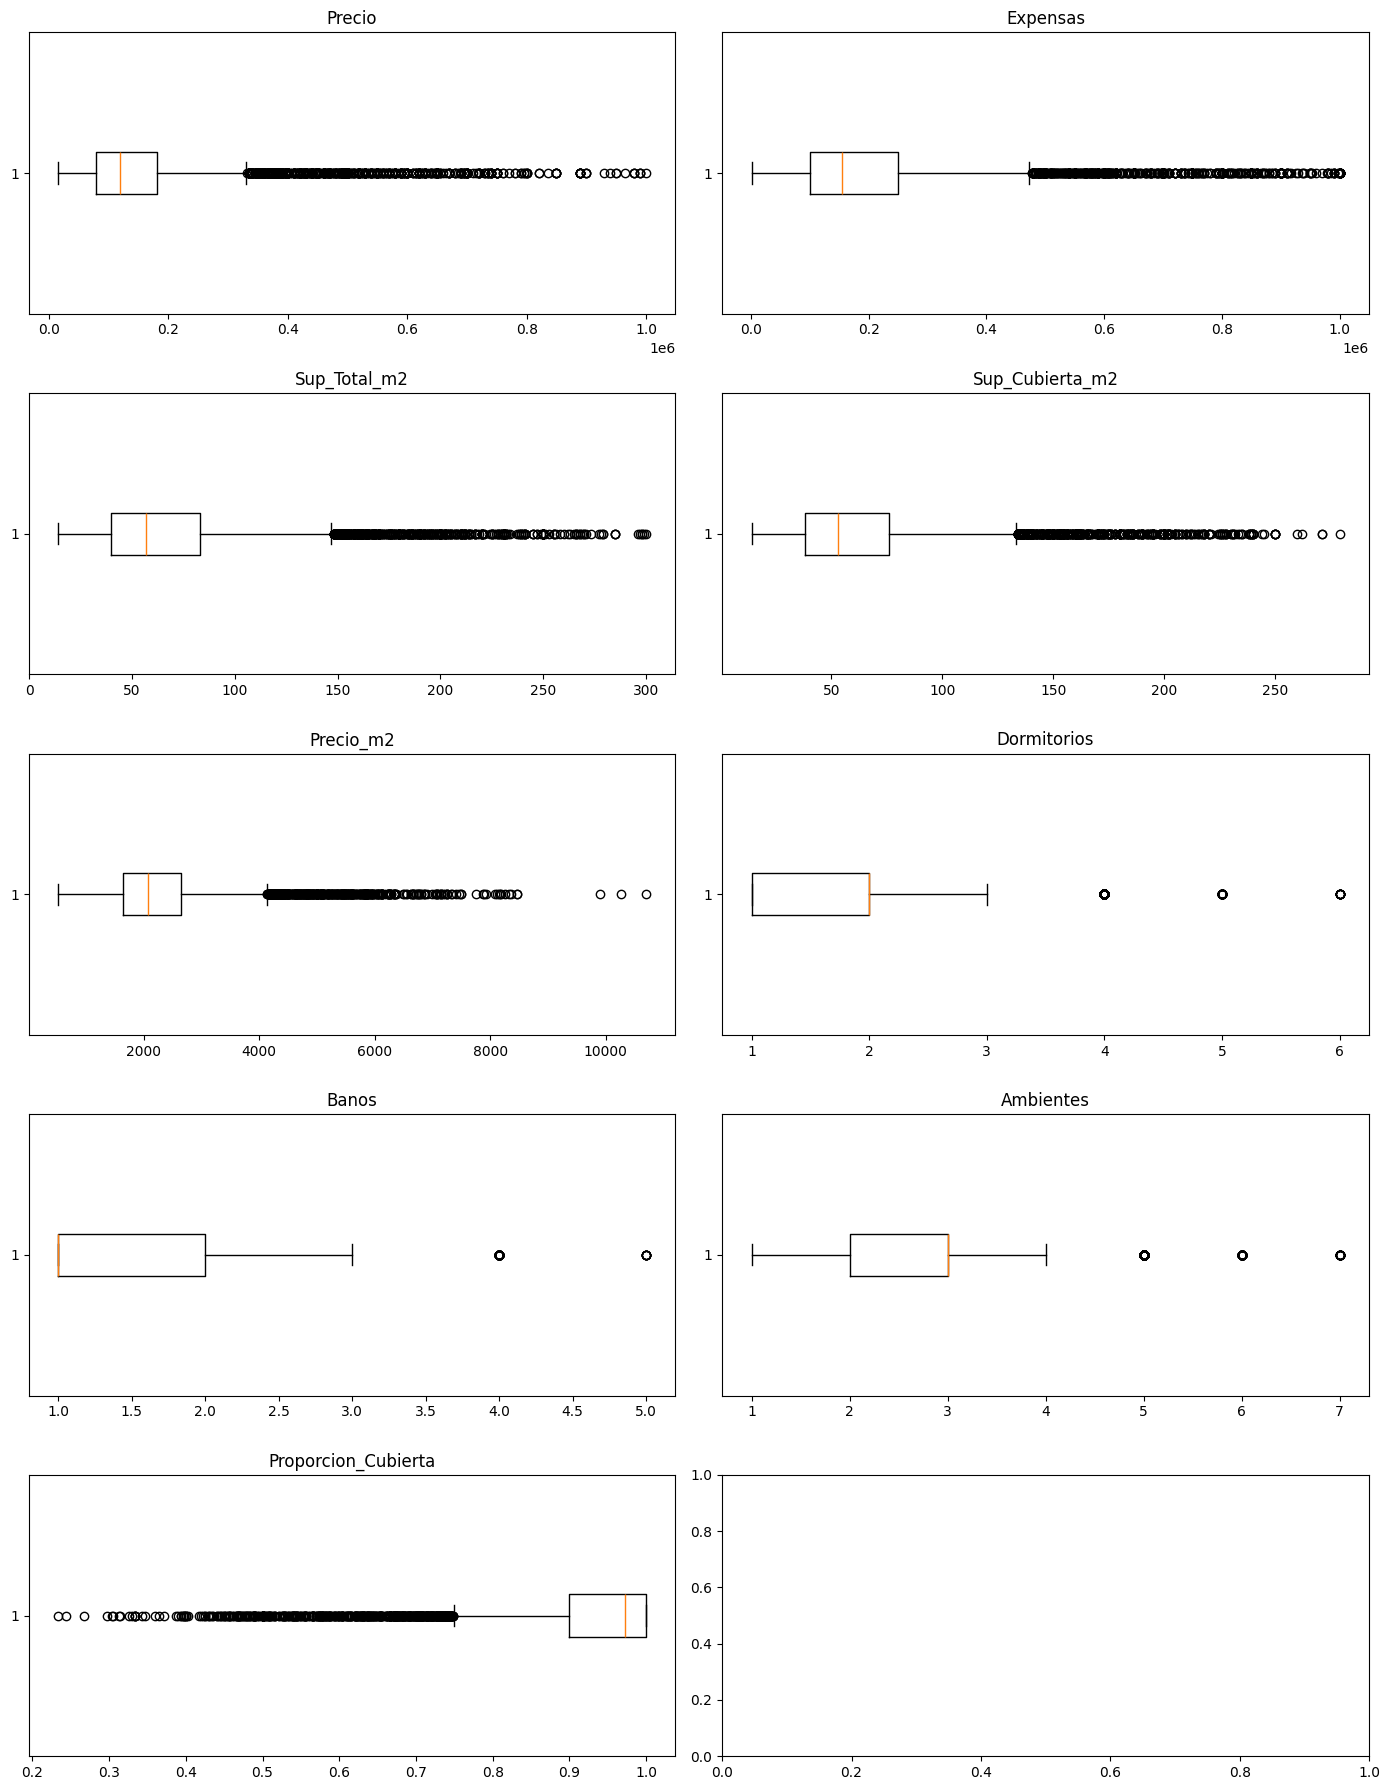

In [56]:
import matplotlib.pyplot as plt

columnas = [
    "Precio",
    "Expensas",
    "Sup_Total_m2",
    "Sup_Cubierta_m2",
    "Precio_m2",
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Proporcion_Cubierta",
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, col in enumerate(columnas):

    axes[i].boxplot(
        df[col].dropna(),
        vert=False
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

- Precio: Distribucion muy sesgada a la derecha. Que es lo que se espera en real state
- Expensas: Tambien se ve asimetria, hay propiedades con expensas mucho mas altas, que tambien peude ser algo normal
- Dormitorios: Dominan 1 y 2 dormitorios. Pocos casos extremos
- Baños: Mayoria entre 1 y 2. Pocos extremos
- Ambientes: Concentracion entre 2 y 4 ambientes
- Antiguedad: Picos fuertes cerca de 40 y 60 anios
- Sup_Total_m2: Cola larga a la derecha, mas larga que la de cubierta logicamente, no hay extremos irreales
- Precio_m2: Cola larga a la derecha. Concentracion fuerte alrededor de 1500-3500
- Prop_cubierta: Muchisimas propiedades cerca de 1 que tiene sentido

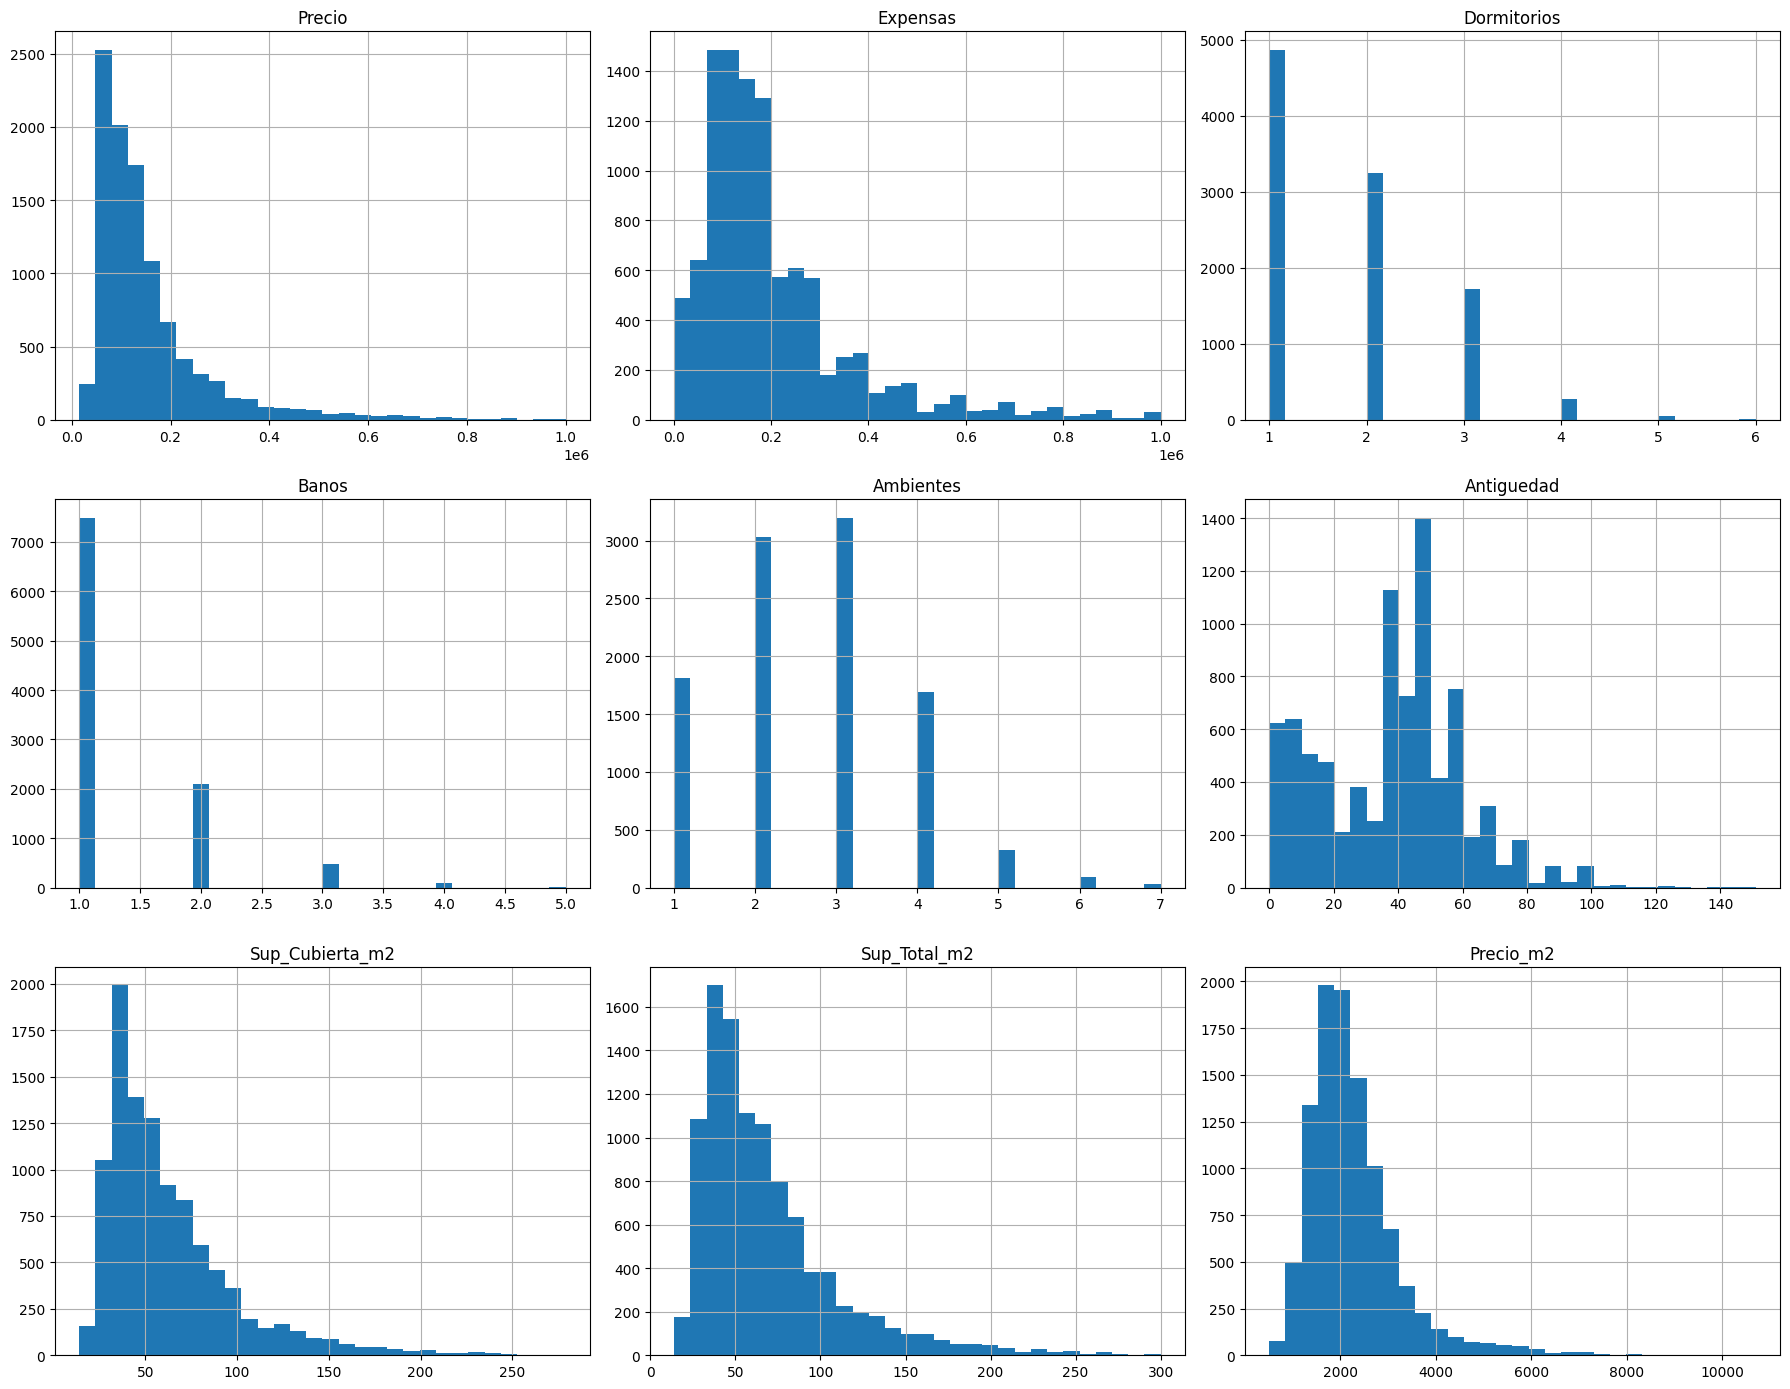

In [57]:
import matplotlib.pyplot as plt

df[cols_cuantitativas].hist(
    figsize=(18, 14),
    bins=30
)

plt.tight_layout()
plt.show()

Las correlaciones muestran que el precio se relaciona fuertemente con Sup_Total_m2, expensas y baños, y en menor medida con ambientes y dormitorios. Por otro lado, la antigüedad presenta una relación negativa con el precio por m², sugiriendo que las propiedades más nuevas tienden a cotizar a valores superiores.

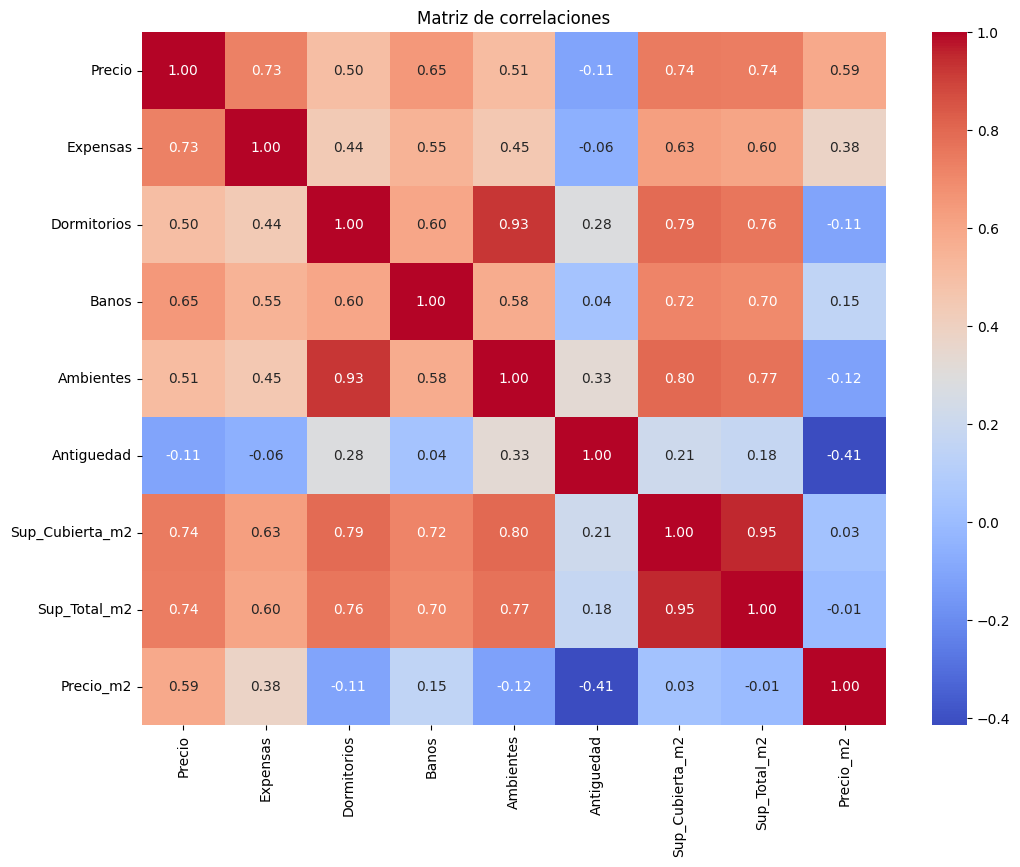

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_corr = [
    "Precio",
    "Expensas",
    "Dormitorios",
    "Banos",
    "Ambientes",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2",
    "Precio_m2",
]

corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(12,9))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlaciones")

plt.show()

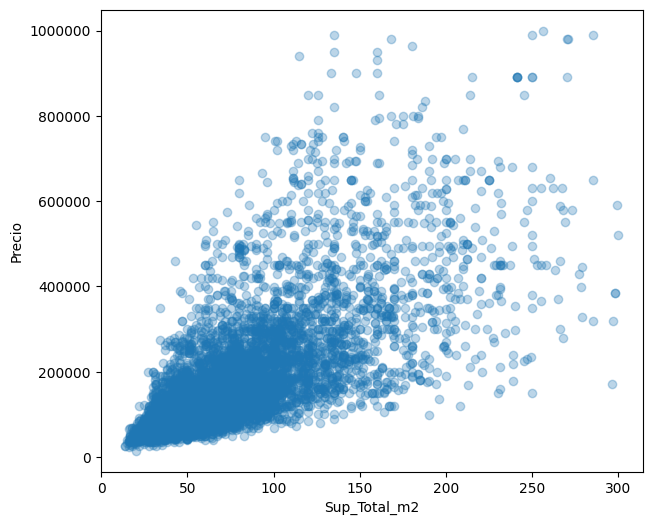

In [59]:
# PRECIO VS SUP_TOTAL_M2

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    df["Sup_Total_m2"],
    df["Precio"],
    alpha=0.3
)

ax.set_xlabel("Sup_Total_m2")
ax.set_ylabel("Precio")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())

ax.ticklabel_format(style="plain", axis="both")

plt.show()

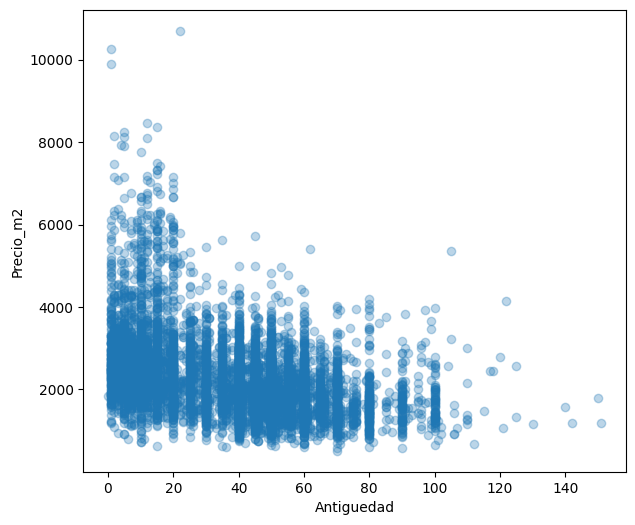

In [60]:
#PRECIO VS ANTIGUEDAD (LAS QUE NO SON NULL)

plt.figure(figsize=(7,6))

plt.scatter(
    df["Antiguedad"],
    df["Precio_m2"],
    alpha=0.3
)

plt.xlabel("Antiguedad")
plt.ylabel("Precio_m2")

plt.show()

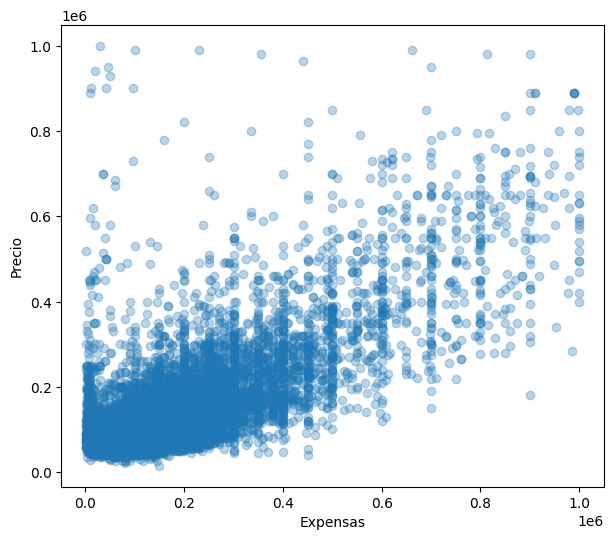

In [61]:
#PRECIO VS EXPENSAS ()

plt.figure(figsize=(7,6))

plt.scatter(
    df["Expensas"],
    df["Precio"],
    alpha=0.3
)

plt.xlabel("Expensas")
plt.ylabel("Precio")

plt.show()

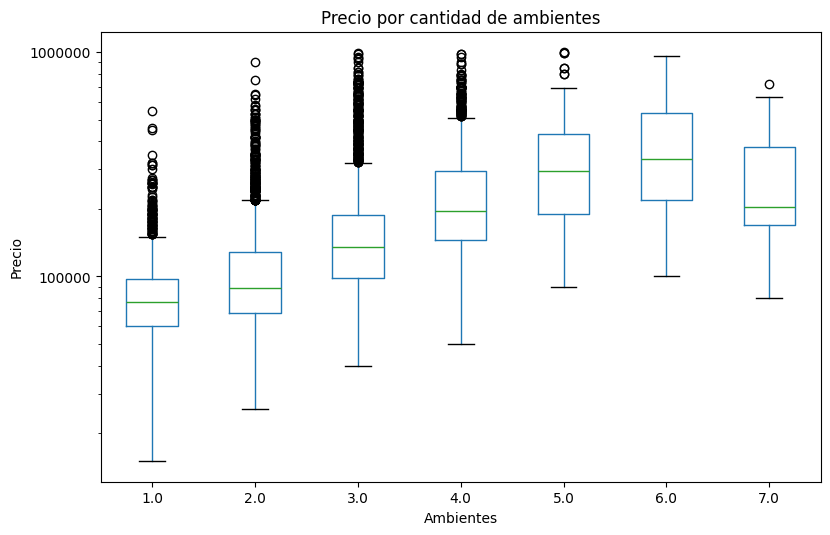

In [62]:
# PRECIO VS AMBIENTES

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(9, 6))

df.boxplot(
    column="Precio",
    by="Ambientes",
    grid=False,
    ax=ax
)

ax.set_title("Precio por cantidad de ambientes")
ax.set_xlabel("Ambientes")
ax.set_ylabel("Precio")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

plt.suptitle("")
plt.show()

Se observa una relación positiva entre el precio y variables como superficie total, expensas y cantidad de ambientes. Además, las propiedades más nuevas tienden a presentar mayores valores de precio por m².

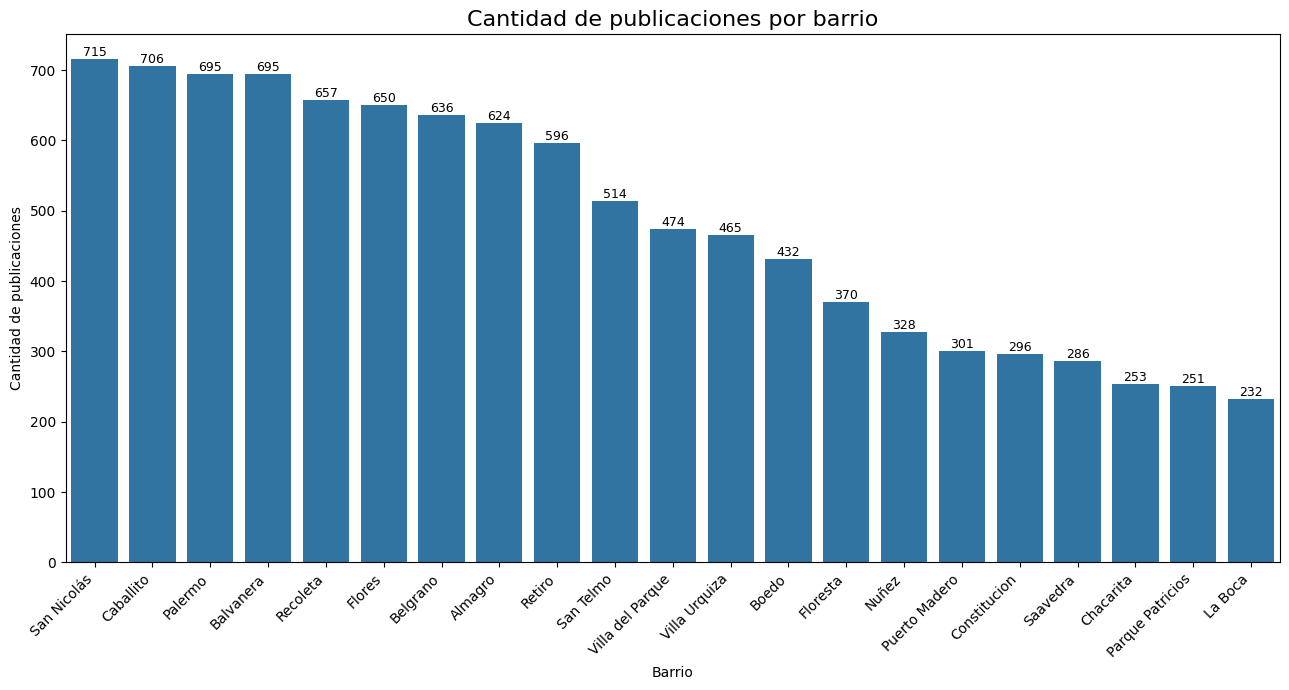

In [63]:
# CANTIDAD DE PUBLICACIONES POR BARRIO

import matplotlib.pyplot as plt
import seaborn as sns

top_barrios = (
    df["Barrio"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    x=top_barrios.index,
    y=top_barrios.values
)

plt.title("Cantidad de publicaciones por barrio", fontsize=16)
plt.xlabel("Barrio")
plt.ylabel("Cantidad de publicaciones")

plt.xticks(
    rotation=45,
    ha="right"
)

for i, valor in enumerate(top_barrios.values):
    ax.text(
        i,
        valor,
        str(valor),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

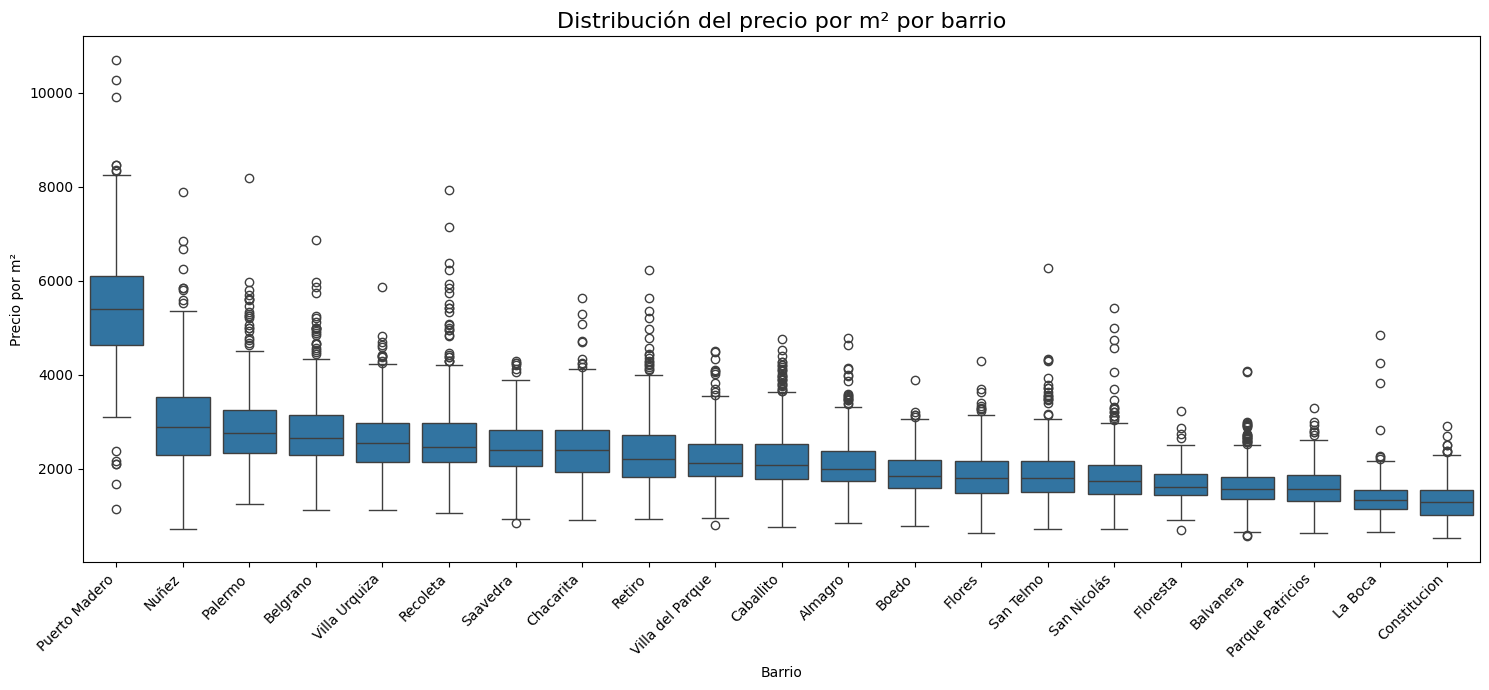

In [64]:
# DISTRIBUCIÓN PRECIO M² POR BARRIO

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

orden_barrios = (
    df.groupby("Barrio")["Precio_m2"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="Barrio",
    y="Precio_m2",
    order=orden_barrios,
    ax=ax
)

ax.set_title("Distribución del precio por m² por barrio", fontsize=16)
ax.set_xlabel("Barrio")
ax.set_ylabel("Precio por m²")

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Puerto Madero presenta, por amplia diferencia, el mayor precio mediano por m2, consolidándose como la zona premium más valorizada de la ciudad. En un segundo nivel aparece Nuñez, seguido por Palermo, Saavedra y Belgrano, que muestran valores relativamente similares entre sí, siendo los barrios mas top de la ciudad.

En el extremo opuesto, Constitución y La Boca registran los menores precios por m², considerablemente por debajo del resto de los barrios analizados. Luego aparecen Balvanera y Parque Patricios

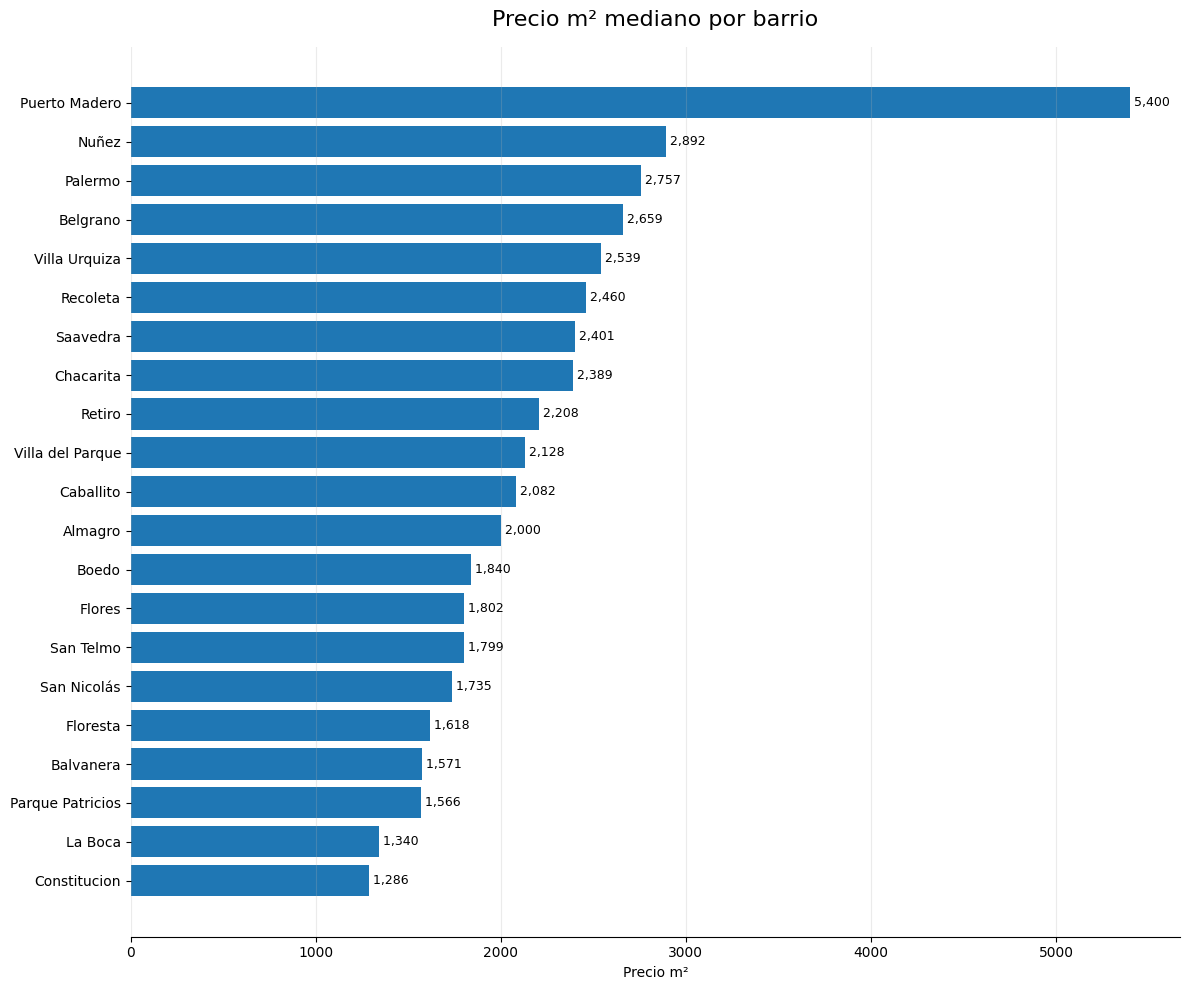

In [65]:
# PRECIO M² MEDIANO POR BARRIO

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

precio_barrio = (
    df.groupby("Barrio")["Precio_m2"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    precio_barrio.index,
    precio_barrio.values
)

ax.set_title("Precio m² mediano por barrio", fontsize=16, pad=15)
ax.set_xlabel("Precio m²")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="x")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.25)

for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor,
        bar.get_y() + bar.get_height() / 2,
        f" {valor:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Se observa que barrios como Puerto Madero concentran la mayor proporción de propiedades con amenities, seguidos por zonas en desarrollo como Saavedra, Núñez y chacarita. En cambio, barrios más tradicionales presentan menores porcentajes. Esto sugiere que la presencia de amenities está fuertemente asociada a desarrollos inmobiliarios más nuevos.

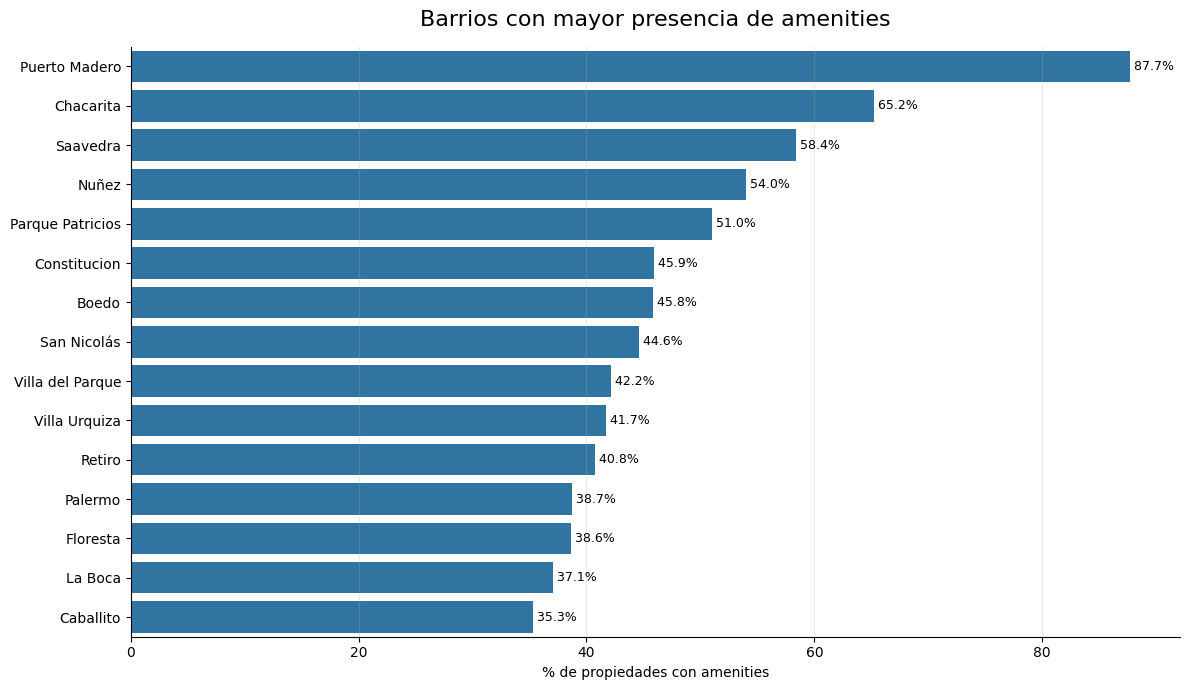

In [66]:
# BARRIOS CON MAYOR PRESENCIA DE AMENITIES

import matplotlib.pyplot as plt
import seaborn as sns

amenities_barrio = (
    df.groupby("Barrio")["Amenities"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    * 100
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=amenities_barrio.values,
    y=amenities_barrio.index,
    ax=ax
)

ax.set_title("Barrios con mayor presencia de amenities", fontsize=16, pad=15)
ax.set_xlabel("% de propiedades con amenities")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", alpha=0.25)

for i, valor in enumerate(amenities_barrio.values):
    ax.text(
        valor,
        i,
        f" {valor:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Los barrios del corredor norte (Puerto Madero, Saavedra, Núñez) presentan mayores niveles de seguridad percibida. La distribución coincide en gran medida con la percepción general de la ciudad.

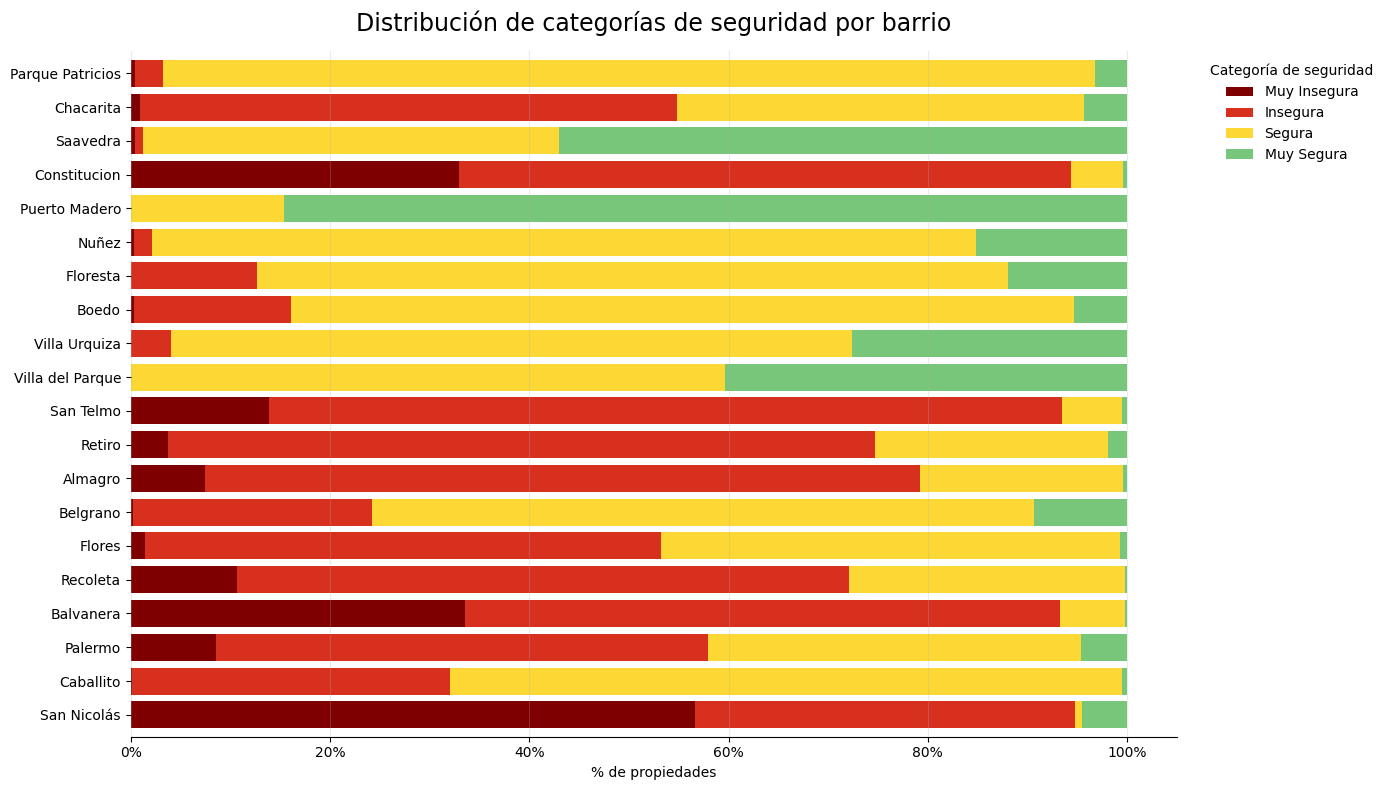

In [67]:
# DISTRIBUCIÓN DE CATEGORÍAS DE SEGURIDAD POR BARRIO

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

orden = [
    "Muy Insegura",
    "Insegura",
    "Media",
    "Segura",
    "Muy Segura"
]

colores = [
    "#7f0000",
    "#d7301f",
    "#fdd835",
    "#78c679",
    "#238443"
]

top_barrios = (
    df["Barrio"]
    .value_counts()
    .head(20)
    .index
)

tabla_seguridad = (
    pd.crosstab(
        df["Barrio"],
        df["Categoria_Seguridad"],
        normalize="index"
    )
    .loc[top_barrios]
    .mul(100)
)

tabla_seguridad = tabla_seguridad[
    [col for col in orden if col in tabla_seguridad.columns]
]

fig, ax = plt.subplots(figsize=(14, 8))

tabla_seguridad.plot(
    kind="barh",
    stacked=True,
    color=colores[:len(tabla_seguridad.columns)],
    ax=ax,
    width=0.8
)

ax.set_title(
    "Distribución de categorías de seguridad por barrio",
    fontsize=17,
    pad=15
)

ax.set_xlabel("% de propiedades")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.25)

ax.legend(
    title="Categoría de seguridad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

Los barrios con menor antiguedad mediana resultan en promedio mas seguros

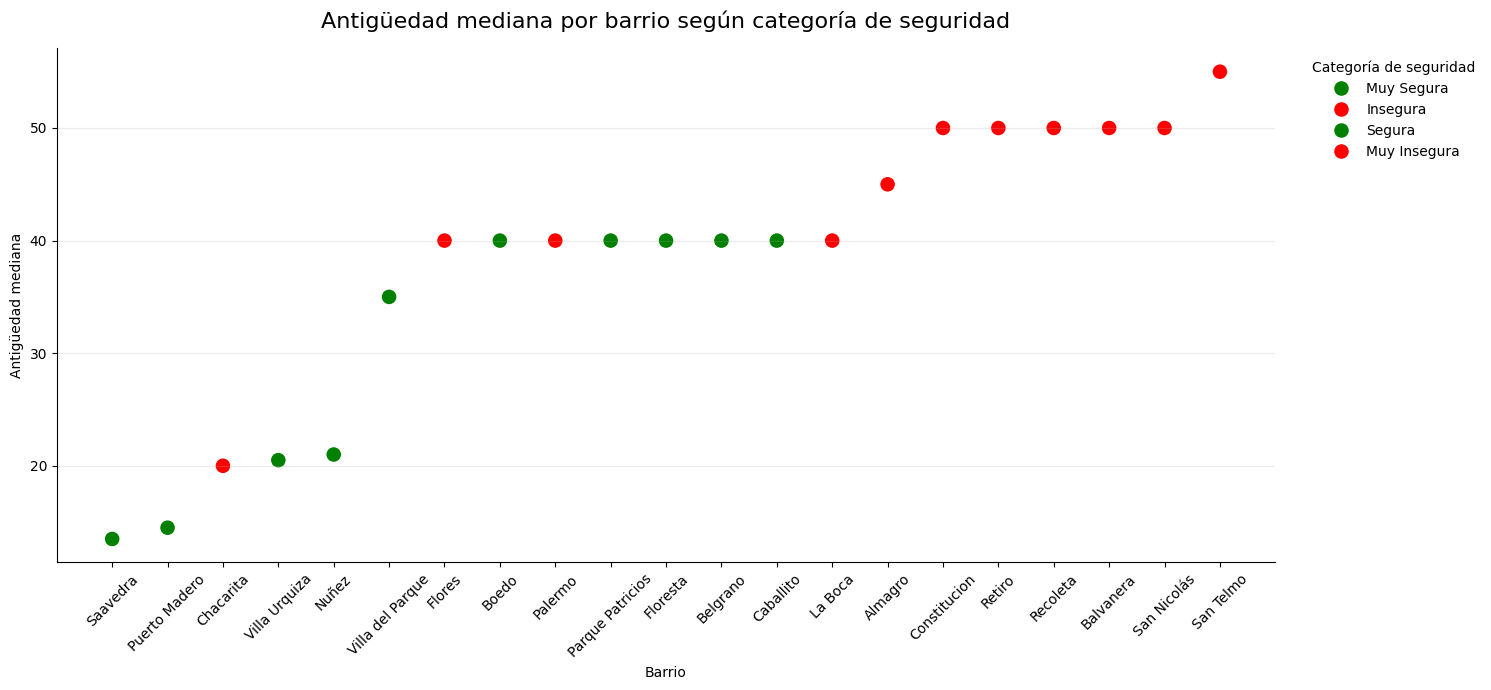

In [68]:
# ANTIGÜEDAD MEDIANA POR BARRIO SEGÚN CATEGORÍA DE SEGURIDAD

import matplotlib.pyplot as plt
import seaborn as sns

orden_seguridad = [
    "Muy Insegura",
    "Insegura",
    "Media",
    "Segura",
    "Muy Segura"
]

colores_seguridad = {
    "Muy Insegura": "red",
    "Insegura": "red",
    "Media": "gold",
    "Segura": "green",
    "Muy Segura": "green"
}

def categoria_seguridad_mas_frecuente(x):
    return x.value_counts().index[0]

resumen_barrio = (
    df.dropna(subset=["Antiguedad", "Precio_m2", "Categoria_Seguridad"])
    .groupby("Barrio")
    .agg(
        Antiguedad_Mediana=("Antiguedad", "median"),
        Precio_m2_Medio=("Precio_m2", "mean"),
        Categoria_Seguridad_Moda=("Categoria_Seguridad", categoria_seguridad_mas_frecuente)
    )
    .sort_values("Antiguedad_Mediana")
)

fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(
    data=resumen_barrio,
    x=resumen_barrio.index,
    y="Antiguedad_Mediana",
    hue="Categoria_Seguridad_Moda",
    palette=colores_seguridad,
    s=130,
    ax=ax
)

ax.set_title("Antigüedad mediana por barrio según categoría de seguridad", fontsize=16, pad=15)

ax.set_xlabel("Barrio")
ax.set_ylabel("Antigüedad mediana")

ax.tick_params(axis="x", rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Categoría de seguridad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

Las variables que más parecen influir en el precio por m² son cochera, seguridad, amenities, balcón aterrazado y categoría de seguridad, ya que las propiedades que poseen estas características presentan precios promedio considerablemente mayores.

También se observa un efecto positivo, aunque más moderado, en variables como aire acondicionado, luminosidad y losa radiante central.

Respeto a Subte_Cerca, en esta variable esperábamos que la cercanía al subte aumentara el valor de las propiedades por una mejor accesibilidad y ubicación, pero los datos muestran lo contrario, por lo que decidimos no tenerla en cuenta

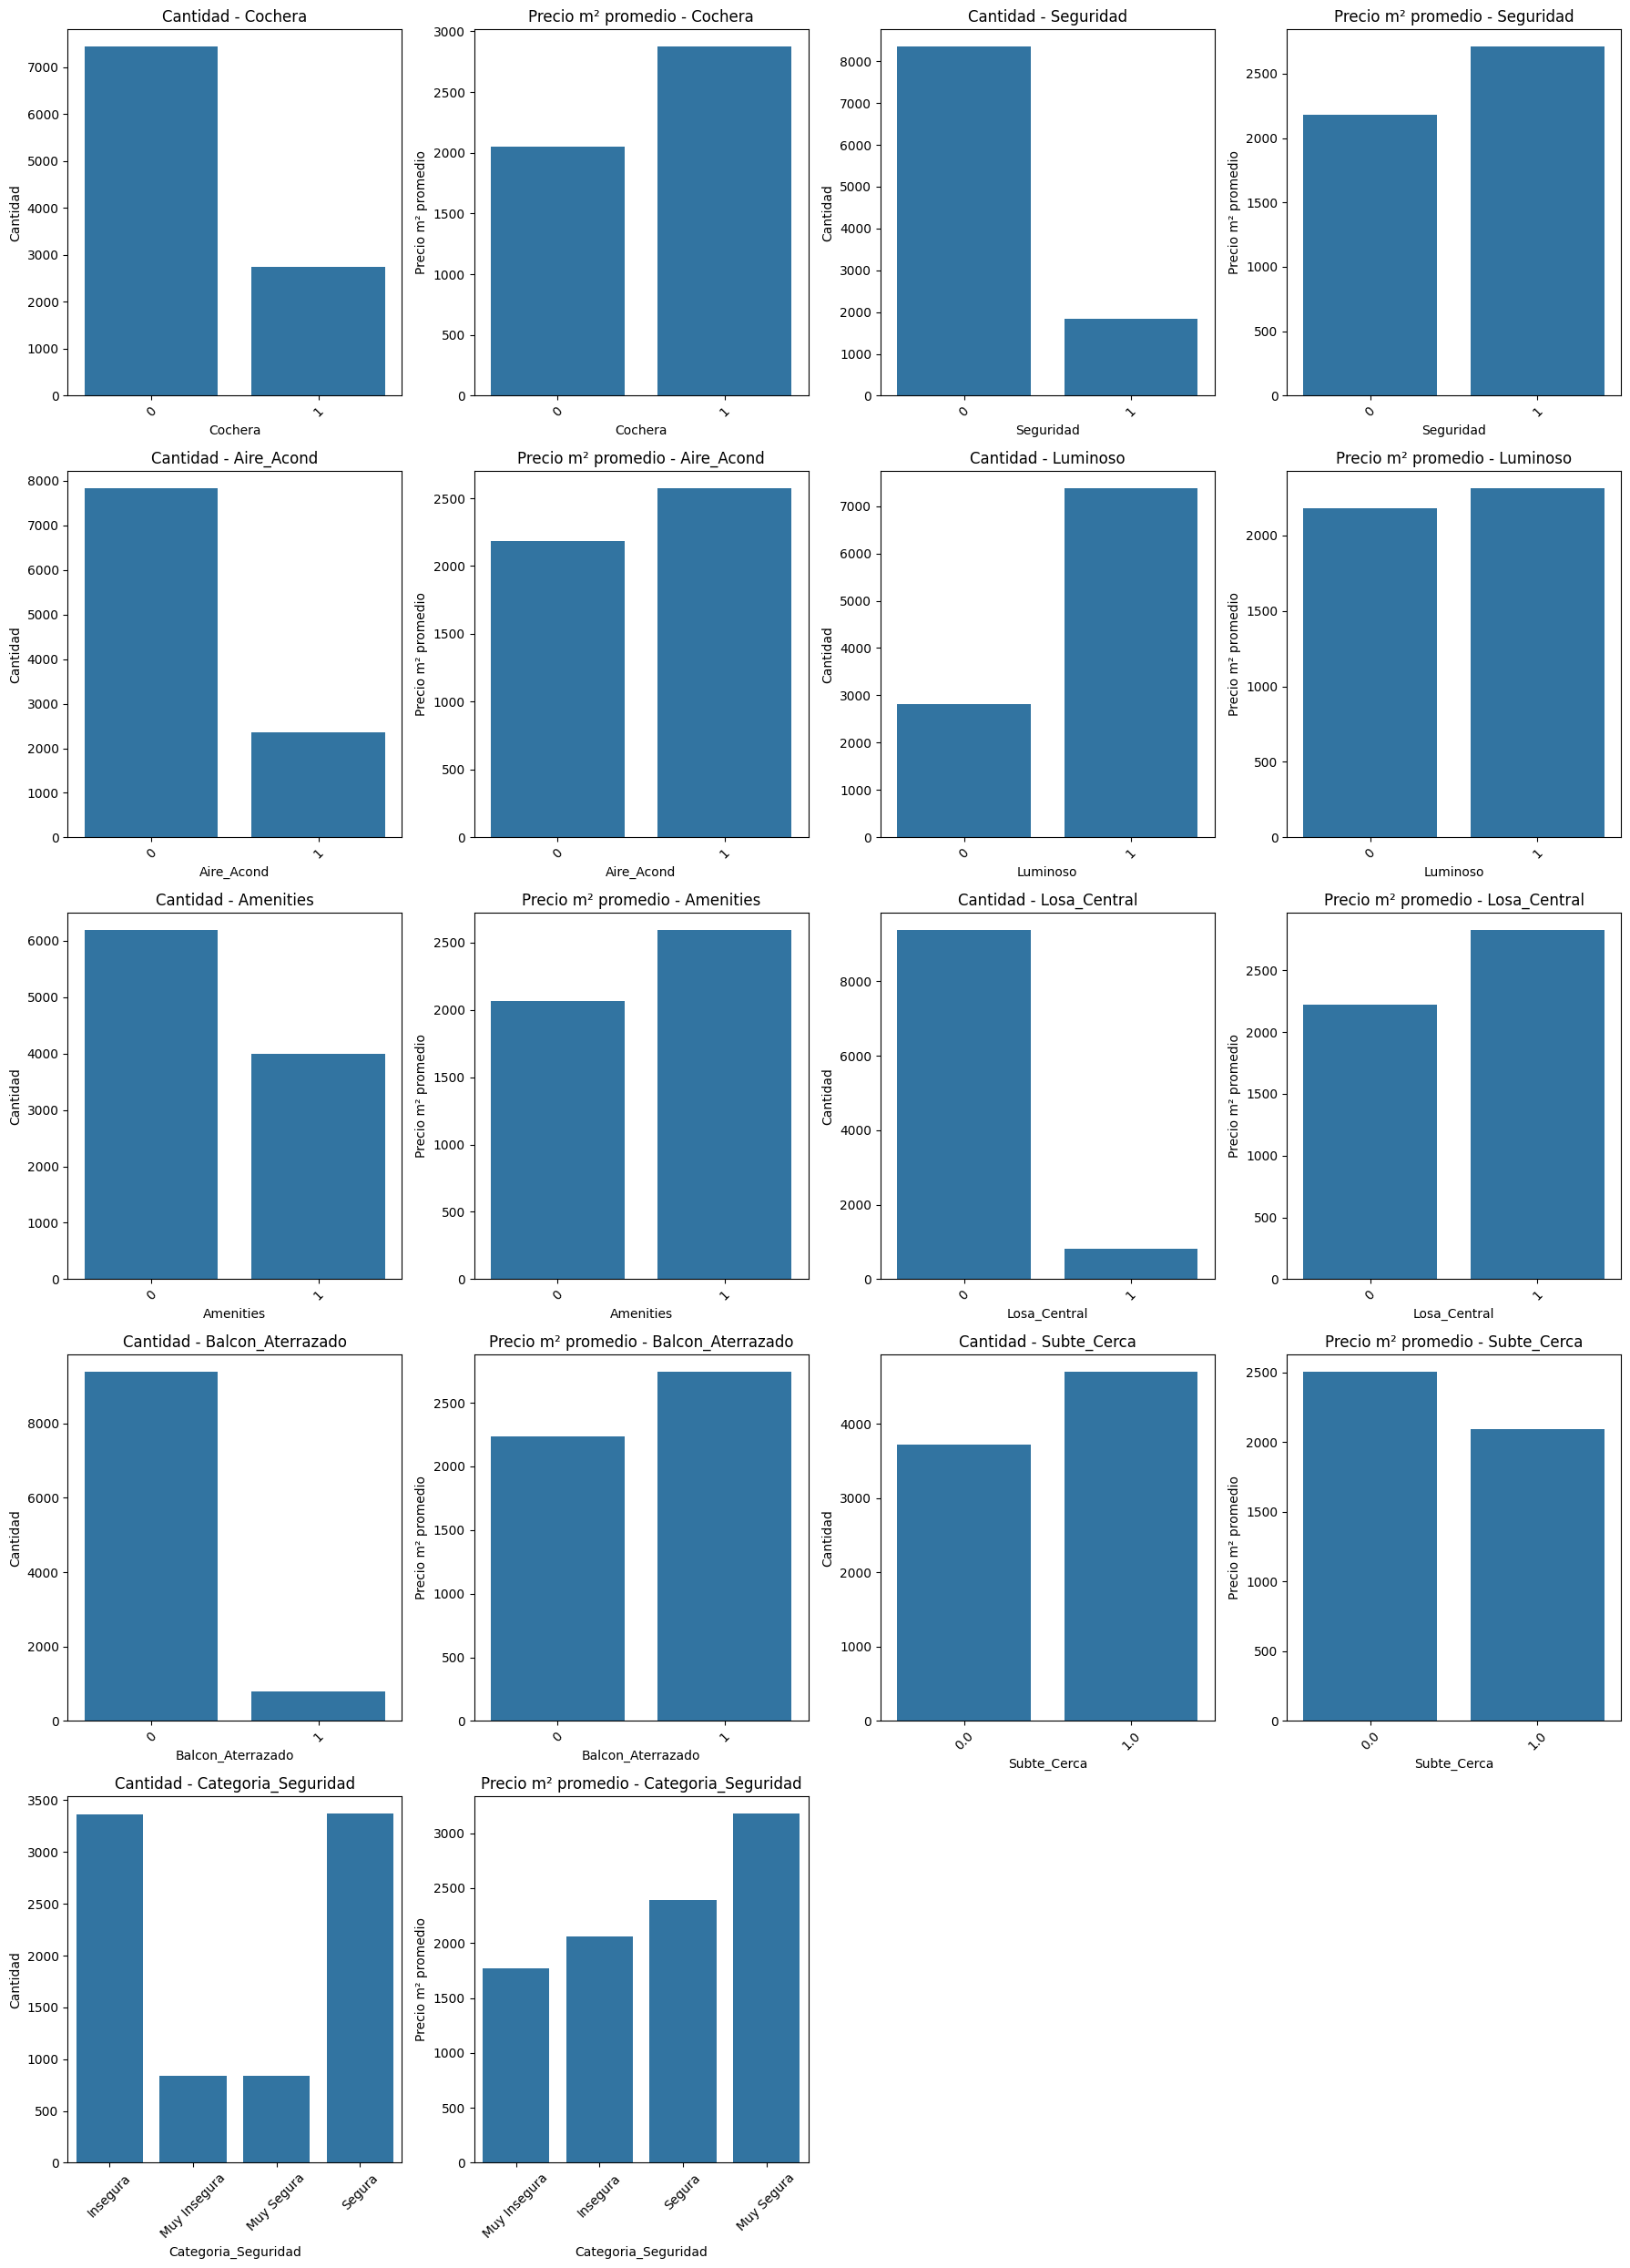

In [69]:
variables = [
    "Cochera",
    "Seguridad",
    "Aire_Acond",
    "Luminoso",
    "Amenities",
    "Losa_Central",
    "Balcon_Aterrazado",
    "Subte_Cerca",
    "Categoria_Seguridad"
]

variables_por_fila = 2

nrows = int(np.ceil(len(variables) / variables_por_fila))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=variables_por_fila * 2,
    figsize=(18, 5 * nrows)
)

axes = np.array(axes).reshape(nrows, variables_por_fila * 2)

for idx, col in enumerate(variables):
    fila = idx // variables_por_fila
    bloque = idx % variables_por_fila

    ax_count = axes[fila, bloque * 2]
    ax_mean = axes[fila, bloque * 2 + 1]

    conteo = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .reset_index()
    )

    conteo.columns = [col, "Cantidad"]

    sns.barplot(
        data=conteo,
        x=col,
        y="Cantidad",
        ax=ax_count
    )

    ax_count.set_title(f"Cantidad - {col}")
    ax_count.set_xlabel(col)
    ax_count.set_ylabel("Cantidad")
    ax_count.tick_params(axis="x", rotation=45)

    promedio = (
        df.groupby(col)["Precio_m2"]
        .mean()
        .sort_values()
        .reset_index()
    )

    sns.barplot(
        data=promedio,
        x=col,
        y="Precio_m2",
        ax=ax_mean
    )

    ax_mean.set_title(f"Precio m² promedio - {col}")
    ax_mean.set_xlabel(col)
    ax_mean.set_ylabel("Precio m² promedio")
    ax_mean.tick_params(axis="x", rotation=45)

total_axes = nrows * variables_por_fila * 2
usados = len(variables) * 2

for i in range(usados, total_axes):
    fila = i // (variables_por_fila * 2)
    columna = i % (variables_por_fila * 2)
    fig.delaxes(axes[fila, columna])

plt.tight_layout()
plt.show()

## Analisis Geografico

In [70]:
import warnings

warnings.filterwarnings("ignore")

**Distribución espacial del precio por m²**

La visualización permite identificar patrones espaciales del mercado inmobiliario, detectando zonas con mayor y menor valorización relativa dentro de la ciudad.

Los colores reflejan el nivel de precio por m²:

verde → valores bajos,
amarillo → valores intermedios,
rojo → valores elevados.

El mapa facilita la identificación de corredores premium y gradientes urbanos de valorización inmobiliaria.

In [71]:
import folium
import branca.colormap as cm


mapa = folium.Map(
    location=[-34.60, -58.44],
    zoom_start=11
)

colormap = cm.LinearColormap(
    colors=["green", "yellow", "red"],
    vmin=df["Precio_m2"].quantile(0.05),
    vmax=df["Precio_m2"].quantile(0.95)
)

for _, row in df.dropna(
    subset=["Latitud", "Longitud"]
).iterrows():

    color = colormap(row["Precio_m2"])

    folium.CircleMarker(
        location=[row["Latitud"], row["Longitud"]],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"""
        Barrio: {row['Barrio']}<br>
        Precio_m2: {row['Precio_m2']:.0f}<br>
        Ambientes: {row['Ambientes']}
        """
    ).add_to(mapa)

colormap.caption = "Precio por m²"
colormap.add_to(mapa)

mapa
mapa.save("mapa1.html")

El mapa de precios por m² presenta una distribución coherente con el mercado de CABA. Los valores más altos se concentran principalmente en barrios del corredor norte y zonas de mayor desarrollo urbano, como Palermo, Belgrano, Núñez y Puerto Madero, mientras que los precios más bajos predominan en sectores del oeste y sur de la ciudad. Además, se observan zonas de transición entre áreas de distinto valor, reflejando la influencia de factores como la ubicación, la conectividad y las características del entorno sobre el precio de las propiedades.

**Mapa general de Oportunidades**

Este mapa identifica propiedades potencialmente subvaluadas dentro de cada barrio considerando simultáneamente:

precio relativo al barrio y con cuantas caracteristicas binarias cumple

Para ello se calcula:
el percentil del precio por m² dentro de cada barrio,
y un score ponderado de las variables binarias del dataset.

Interpretación visual:
tamaño del círculo → mayor score,
verde → oportunidades excepcionales,
amarillo → muy buenas oportunidades,
rojo → oportunidades moderadas.

El objetivo es detectar propiedades que presentan características deseables a precios relativamente bajos respecto a su entorno inmediato.

In [72]:
import folium

df["Percentil_Precio_Barrio"] = (
    df.groupby("Barrio")["Precio_m2"]
    .rank(pct=True)
)

df["Score"] = (
    df["Cochera"] * 2 +
    df["Seguridad"] * 3 +
    df["Amenities"] * 2 +
    df["Aire_Acond"] * 0.5 +
    df["Balcon_Aterrazado"] * 1 +
    df["Losa_Central"] * 2 +
    df["A_Estrenar"] * 1
)

df.loc[df["Categoria_Seguridad"] == "Muy Segura", "Score"] += 1
df.loc[df["Categoria_Seguridad"] == "Muy Insegura", "Score"] -= 1

oportunidades = df[
    (df["Percentil_Precio_Barrio"] <= 0.1) &
    (df["Score"] >= 6)
].copy()

print(oportunidades.shape)

mapa_oportunidades_general = folium.Map(
    location=[-34.60, -58.44],
    zoom_start=11,
    tiles="CartoDB positron"
)

for _, row in oportunidades.dropna(
    subset=["Latitud", "Longitud"]
).iterrows():

    if row["Percentil_Precio_Barrio"] <= 0.03:
        color = "green"

    elif row["Percentil_Precio_Barrio"] <= 0.06:
        color = "yellow"

    else:
        color = "red"

    radio = min(12, 3 + row["Score"])

    popup = f"""
    <b>Barrio:</b> {row['Barrio']}<br>
    <b>Precio m²:</b> {row['Precio_m2']:.0f}<br>
    <b>Percentil Barrio:</b> {row['Percentil_Precio_Barrio']:.2f}<br>
    <b>Score:</b> {row['Score']}<br>
    <b>Ambientes:</b> {row['Ambientes']}<br>
    <b>Sup Total:</b> {row['Sup_Total_m2']} m²
    """

    folium.CircleMarker(
        location=[row["Latitud"], row["Longitud"]],
        radius=radio,
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.60,
        popup=popup
    ).add_to(mapa_oportunidades_general)

mapa_oportunidades_general
mapa_oportunidades_general.save("mapa2general.html")

(50, 28)
